In [1]:
# !gdown 1jxSR9Cov4XaTXY1kPUnMFk7MaXR-bcQ5

In [2]:
FILE_PATH = 'Transactions.csv'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pywaffle import Waffle
import numpy as np
pd.set_option('display.float_format', '{:,.5f}'.format)


In [4]:
def format_num(num):
  return "{:,}".format(num)

def df_status(df):
    print(f"{format_num(len(df))} Samples & {len(df.columns)} Features")

In [5]:
df = pd.read_csv(FILE_PATH)

In [6]:
df.columns
df.head()

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,rooms_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3
0,3-9-2006-163,9,3,هبات,Gifts,هبه,Grant,16-10-2006,4,فيلا,...,NaN,0,"3,162.42000","12,000,000.00000","3,794.56000",NaN,NaN,3.00000,1.00000,0.00000
1,3-9-2019-2944,9,3,هبات,Gifts,هبه,Grant,13-11-2019,1,أرض,...,NaN,0,209.09000,"916,659.00000","4,384.04000",NaN,NaN,2.00000,4.00000,0.00000
2,2-13-1999-347,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,22-03-1999,1,أرض,...,NaN,0,"1,062.72000","1,200,000.00000","1,129.18000",NaN,NaN,1.00000,1.00000,0.00000
3,2-13-2001-547,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,23-07-2001,2,مبنى,...,NaN,0,"1,393.55000","3,500,000.00000","2,511.57000",NaN,NaN,5.00000,1.00000,0.00000
4,2-13-2020-9477,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,30-11-2020,2,مبنى,...,NaN,0,278.71000,"2,500,000.00000","8,969.90000",NaN,NaN,1.00000,1.00000,0.00000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1665112 entries, 0 to 1665111
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1665112 non-null  str    
 1   procedure_id          1665112 non-null  int64  
 2   trans_group_id        1665112 non-null  int64  
 3   trans_group_ar        1665112 non-null  str    
 4   trans_group_en        1665112 non-null  str    
 5   procedure_name_ar     1665112 non-null  str    
 6   procedure_name_en     1665112 non-null  str    
 7   instance_date         1665112 non-null  str    
 8   property_type_id      1665112 non-null  int64  
 9   property_type_ar      1665112 non-null  str    
 10  property_type_en      1665112 non-null  str    
 11  property_sub_type_id  1330409 non-null  float64
 12  property_sub_type_ar  1330409 non-null  str    
 13  property_sub_type_en  1330409 non-null  str    
 14  property_usage_ar     1665112 non-null  str  

In [8]:
df['procedure_name_en'].unique()

<StringArray>
[                                           'Grant',
                            'Mortgage Registration',
                                             'Sell',
                              'Adding Land By Sell',
                                  'Modify Mortgage',
                              'Lease to Own Modify',
                                'Mortgage Transfer',
                        'Lease to Own Registration',
                         'Development Registration',
                                     'Delayed Sell',
                          'Sell - Pre registration',
                        'Mortgage Pre-Registration',
                       'Lease Finance Registration',
                  'Portfolio Mortgage Registration',
                                 'Delayed Mortgage',
       'Lease to Own Registration Pre-Registration',
                            'Lease to Own Transfer',
                'Delayed Lease to Own Registration',
                           'Gran

# Data Pre-Processing


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1665112 entries, 0 to 1665111
Data columns (total 46 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   transaction_id        1665112 non-null  str    
 1   procedure_id          1665112 non-null  int64  
 2   trans_group_id        1665112 non-null  int64  
 3   trans_group_ar        1665112 non-null  str    
 4   trans_group_en        1665112 non-null  str    
 5   procedure_name_ar     1665112 non-null  str    
 6   procedure_name_en     1665112 non-null  str    
 7   instance_date         1665112 non-null  str    
 8   property_type_id      1665112 non-null  int64  
 9   property_type_ar      1665112 non-null  str    
 10  property_type_en      1665112 non-null  str    
 11  property_sub_type_id  1330409 non-null  float64
 12  property_sub_type_ar  1330409 non-null  str    
 13  property_sub_type_en  1330409 non-null  str    
 14  property_usage_ar     1665112 non-null  str  

In [10]:
df['parsed_date'] = pd.to_datetime(df['instance_date'], format='%d-%m-%Y')

In [11]:
df['property_sub_type_en'].unique()

<StringArray>
[                 nan,             'Office',               'Flat',
               'Shop',              'Store',              'Villa',
    'Hotel Apartment',        'Hotel Rooms',              'Hotel',
             'Clinic',           'Building',          'Warehouse',
 'Stacked Townhouses',           'Workshop',    'Sized Partition',
         'Show Rooms',          'Gymnasium',               'Unit',
            'Parking']
Length: 19, dtype: str

In [12]:
print("\n\nLast 10 Entries \n\n")
print(df.sort_values(by='parsed_date').tail(10))
print("\n\n-----------------")
print("\n\nFirst 10 Entries \n\n")
print(df.sort_values(by='parsed_date').head(10))



Last 10 Entries 


           transaction_id  procedure_id  trans_group_id trans_group_ar  \
1202936    1-11-2026-7315            11               1        مبايعات   
202712   1-102-2026-17220           102               1        مبايعات   
787567     1-41-2026-3020            41               1        مبايعات   
834752     1-11-2026-7071            11               1        مبايعات   
1359767  1-102-2026-17349           102               1        مبايعات   
1127727  1-102-2026-17438           102               1        مبايعات   
523002   1-102-2026-17187           102               1        مبايعات   
299852   1-102-2026-17611           102               1        مبايعات   
840667      2-14-2026-218            14               2           رهون   
539343   1-102-2026-17140           102               1        مبايعات   

        trans_group_en  procedure_name_ar        procedure_name_en  \
1202936          Sales                بيع                     Sell   
202712           Sales  

In [13]:
# the first four transactions are from 1416 to 1422 which seems weird and can be removed. They will skew the data unnecessarily

### We have transaction data from 18th January, 1966 to 12th June, 2025

In [14]:
df[df['parsed_date'].isna()]

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date


In [15]:
df1 = df[4:].reset_index(drop=True)

In [16]:
print(f"Total transactions earlier: {len(df)}")
print(f"Total transactions now: {len(df1)}")

Total transactions earlier: 1665112
Total transactions now: 1665108


In [17]:
print(f"Earliest transaction earlier was {df.loc[0, 'parsed_date']}")
print(f"Earliest transaction now is {df1.loc[0, 'parsed_date']}")

Earliest transaction earlier was 2006-10-16 00:00:00
Earliest transaction now is 2020-11-30 00:00:00


In [18]:
df1.head()

,transaction_id,procedure_id,trans_group_id,trans_group_ar,trans_group_en,procedure_name_ar,procedure_name_en,instance_date,property_type_id,property_type_ar,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
0,2-13-2020-9477,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,30-11-2020,2,مبنى,...,0,278.71000,"2,500,000.00000","8,969.90000",NaN,NaN,1.00000,1.00000,0.00000,2020-11-30
1,3-9-2002-70,9,3,هبات,Gifts,هبه,Grant,29-05-2002,4,فيلا,...,0,276.39000,"500,000.00000","1,809.04000",NaN,NaN,1.00000,1.00000,0.00000,2002-05-29
2,1-11-2013-15239,11,1,مبايعات,Sales,بيع,Sell,16-05-2013,4,فيلا,...,0,382.67000,"2,000,000.00000","5,226.44000",NaN,NaN,1.00000,1.00000,0.00000,2013-05-16
3,1-4-2012-13,4,1,مبايعات,Sales,إضافة أرض بالبيع,Adding Land By Sell,19-04-2012,2,مبنى,...,0,346.81000,"920,700.00000","2,654.77000",NaN,NaN,1.00000,1.00000,0.00000,2012-04-19
4,2-13-1999-532,13,2,رهون,Mortgages,تسجيل رهن,Mortgage Registration,26-04-1999,4,فيلا,...,0,"3,626.93000","1,900,000.00000",523.86000,NaN,NaN,1.00000,1.00000,0.00000,1999-04-26


## Dropping Non-Informative Arabic Columns


In [19]:
ar_columns = [column for column in df1.columns.to_list() if column.endswith('_ar')]
ar_columns

['trans_group_ar',
 'procedure_name_ar',
 'property_type_ar',
 'property_sub_type_ar',
 'property_usage_ar',
 'reg_type_ar',
 'area_name_ar',
 'building_name_ar',
 'project_name_ar',
 'master_project_ar',
 'nearest_landmark_ar',
 'nearest_metro_ar',
 'nearest_mall_ar',
 'rooms_ar']

In [20]:
df2 = df1.drop(columns=ar_columns)

In [21]:
df2.columns

Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en',
       'procedure_name_en', 'instance_date', 'property_type_id',
       'property_type_en', 'property_sub_type_id', 'property_sub_type_en',
       'property_usage_en', 'reg_type_id', 'reg_type_en', 'area_id',
       'area_name_en', 'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [22]:
df2.property_usage_en.unique()

<StringArray>
[                          'Residential',
                            'Commercial',
                            'Industrial',
              'Residential / Commercial',
                                 'Other',
                             'Multi-Use',
                               'Storage',
                          'Agricultural',
                          'Hospitality ',
               'Industrial / Commercial',
 'Industrial / Commercial / Residential']
Length: 11, dtype: str

## Filtering observations by Property Classifications

`property_usage_en` column

We need to make a decision to use which all properties from `property_usage_en`.
eg: If we want to just use Residential properties, then we need to filter out the usage types of following:
1. Residential
2. Residential / Commercial
3. Industrial / Commercial / Residential
4. Multi-Use

_Multi-Use might be removed seeing it's values_

In [23]:
allowed_usages = ['Residential', 'Residential / Commercial', 'Industrial / Commercial / Residential', 'Multi-Use']
res_df = df2[df2['property_usage_en'].isin(allowed_usages)]

In [24]:
res_df.info()

<class 'pandas.DataFrame'>
Index: 1406101 entries, 0 to 1665107
Data columns (total 33 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1406101 non-null  str           
 1   procedure_id          1406101 non-null  int64         
 2   trans_group_id        1406101 non-null  int64         
 3   trans_group_en        1406101 non-null  str           
 4   procedure_name_en     1406101 non-null  str           
 5   instance_date         1406101 non-null  str           
 6   property_type_id      1406101 non-null  int64         
 7   property_type_en      1406101 non-null  str           
 8   property_sub_type_id  1200852 non-null  float64       
 9   property_sub_type_en  1200852 non-null  str           
 10  property_usage_en     1406101 non-null  str           
 11  reg_type_id           1406101 non-null  int64         
 12  reg_type_en           1406101 non-null  str           
 13

Property Type Evaluation

In [25]:
df_status(res_df)

1,406,101 Samples & 33 Features


In [26]:
res_df.property_type_en.unique()

<StringArray>
['Building', 'Villa', 'Land', 'Unit']
Length: 4, dtype: str

We have 'Villa', 'Building', 'Land', 'Unit' types of properties

In [27]:
# For this model, let's focus on "Unit" type

res_units = res_df[res_df['property_type_en'] == 'Unit']
res_units2 = res_units.drop(columns=['property_type_en', 'property_type_id'])
res_units2.info()

<class 'pandas.DataFrame'>
Index: 1055514 entries, 370 to 1665107
Data columns (total 31 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1055514 non-null  str           
 1   procedure_id          1055514 non-null  int64         
 2   trans_group_id        1055514 non-null  int64         
 3   trans_group_en        1055514 non-null  str           
 4   procedure_name_en     1055514 non-null  str           
 5   instance_date         1055514 non-null  str           
 6   property_sub_type_id  1055514 non-null  float64       
 7   property_sub_type_en  1055514 non-null  str           
 8   property_usage_en     1055514 non-null  str           
 9   reg_type_id           1055514 non-null  int64         
 10  reg_type_en           1055514 non-null  str           
 11  area_id               1055514 non-null  int64         
 12  area_name_en          1055514 non-null  str           
 

## Property Subtype

In [28]:
res_units2.property_sub_type_en.unique()

<StringArray>
['Flat', 'Stacked Townhouses', 'Unit']
Length: 3, dtype: str

We have 3 types of sub types now:

1. Flat
2. Stacked Townhouses
3. Unit

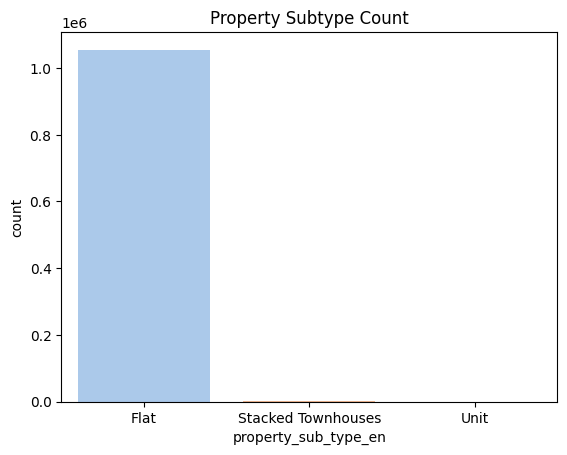

In [29]:
sns.countplot(data=res_units2, x='property_sub_type_en', legend='auto', stat='count', palette='pastel', hue='property_sub_type_en')
plt.title('Property Subtype Count')
plt.show()

In [30]:
res_units2.property_sub_type_en.value_counts()

property_sub_type_en
Flat                  1054990
Stacked Townhouses        522
Unit                        2
Name: count, dtype: int64

Since we don't want Stacked Townhouses for now and the unit is only 1 in count. It's better to just filter out the flats.

In [31]:
flats_df = res_units2[res_units2['property_sub_type_en'] == 'Flat']
flats_df2 = flats_df.drop(columns=['property_sub_type_en', 'property_sub_type_id'])
flats_df2.info()

<class 'pandas.DataFrame'>
Index: 1054990 entries, 370 to 1665107
Data columns (total 29 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1054990 non-null  str           
 1   procedure_id          1054990 non-null  int64         
 2   trans_group_id        1054990 non-null  int64         
 3   trans_group_en        1054990 non-null  str           
 4   procedure_name_en     1054990 non-null  str           
 5   instance_date         1054990 non-null  str           
 6   property_usage_en     1054990 non-null  str           
 7   reg_type_id           1054990 non-null  int64         
 8   reg_type_en           1054990 non-null  str           
 9   area_id               1054990 non-null  int64         
 10  area_name_en          1054990 non-null  str           
 11  building_name_en      1054990 non-null  str           
 12  project_number        831676 non-null   float64       
 

## 9,11,523 Samples and 29 Features

We can remove _instance_date_, since we already have _parsed_date_

In [32]:
flats_df3 = flats_df2.drop(columns=['instance_date'])
flats_df3.shape

(1054990, 28)

## 9,11,523 Samples and 28 Features

In [33]:
flats_df3.info()

<class 'pandas.DataFrame'>
Index: 1054990 entries, 370 to 1665107
Data columns (total 28 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1054990 non-null  str           
 1   procedure_id          1054990 non-null  int64         
 2   trans_group_id        1054990 non-null  int64         
 3   trans_group_en        1054990 non-null  str           
 4   procedure_name_en     1054990 non-null  str           
 5   property_usage_en     1054990 non-null  str           
 6   reg_type_id           1054990 non-null  int64         
 7   reg_type_en           1054990 non-null  str           
 8   area_id               1054990 non-null  int64         
 9   area_name_en          1054990 non-null  str           
 10  building_name_en      1054990 non-null  str           
 11  project_number        831676 non-null   float64       
 12  project_name_en       831676 non-null   str           
 

In [34]:
flats_df3.property_usage_en.value_counts()

property_usage_en
Residential    1054990
Name: count, dtype: int64

## Property Usage

Only 1 value type now exists, we can remove it.

In [35]:
flats_df4 = flats_df3.drop(columns=['property_usage_en'])
flats_df4.shape

(1054990, 27)

In [36]:
flats_df4.info()

<class 'pandas.DataFrame'>
Index: 1054990 entries, 370 to 1665107
Data columns (total 27 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1054990 non-null  str           
 1   procedure_id          1054990 non-null  int64         
 2   trans_group_id        1054990 non-null  int64         
 3   trans_group_en        1054990 non-null  str           
 4   procedure_name_en     1054990 non-null  str           
 5   reg_type_id           1054990 non-null  int64         
 6   reg_type_en           1054990 non-null  str           
 7   area_id               1054990 non-null  int64         
 8   area_name_en          1054990 non-null  str           
 9   building_name_en      1054990 non-null  str           
 10  project_number        831676 non-null   float64       
 11  project_name_en       831676 non-null   str           
 12  master_project_en     997332 non-null   str           
 

## 9,11,523 Samples & 27 Features

## Registration type

## 12,61,949 samples & 33 features left

## Dropping Non-Informative Identifier Columns

In [37]:
flats_df4.columns

Index(['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_en',
       'procedure_name_en', 'reg_type_id', 'reg_type_en', 'area_id',
       'area_name_en', 'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [38]:
flats_df4.info()

<class 'pandas.DataFrame'>
Index: 1054990 entries, 370 to 1665107
Data columns (total 27 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   transaction_id        1054990 non-null  str           
 1   procedure_id          1054990 non-null  int64         
 2   trans_group_id        1054990 non-null  int64         
 3   trans_group_en        1054990 non-null  str           
 4   procedure_name_en     1054990 non-null  str           
 5   reg_type_id           1054990 non-null  int64         
 6   reg_type_en           1054990 non-null  str           
 7   area_id               1054990 non-null  int64         
 8   area_name_en          1054990 non-null  str           
 9   building_name_en      1054990 non-null  str           
 10  project_number        831676 non-null   float64       
 11  project_name_en       831676 non-null   str           
 12  master_project_en     997332 non-null   str           
 

In [39]:
for column in flats_df4.columns.to_list():
    print(f"Unique value count for {column}: {res_df[column].nunique()}")

Unique value count for transaction_id: 1406101
Unique value count for procedure_id: 49
Unique value count for trans_group_id: 3
Unique value count for trans_group_en: 3
Unique value count for procedure_name_en: 49
Unique value count for reg_type_id: 2
Unique value count for reg_type_en: 2
Unique value count for area_id: 216
Unique value count for area_name_en: 216
Unique value count for building_name_en: 4446
Unique value count for project_number: 2912
Unique value count for project_name_en: 2908
Unique value count for master_project_en: 159
Unique value count for nearest_landmark_en: 14
Unique value count for nearest_metro_en: 55
Unique value count for nearest_mall_en: 5
Unique value count for rooms_en: 15
Unique value count for has_parking: 2
Unique value count for procedure_area: 71074
Unique value count for actual_worth: 302489
Unique value count for meter_sale_price: 799228
Unique value count for rent_value: 13090
Unique value count for meter_rent_price: 25659
Unique value count f

In [40]:
## Dropping transaction_id column
flats_df5 = flats_df4.drop(columns=['transaction_id'])

In [41]:
flats_df5.head()

,procedure_id,trans_group_id,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
370,11,1,Sales,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 1,NaN,...,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,1.00000,1.00000,0.00000,2016-02-15
371,110,1,Sales,Lease to Own Registration,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 1,NaN,...,1,316.71000,"4,641,888.00000","14,656.59000",NaN,NaN,2.00000,2.00000,2.00000,2009-11-24
372,11,1,Sales,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 2,NaN,...,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,1.00000,1.00000,0.00000,2018-05-01
379,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,1.00000,2.00000,0.00000,2024-01-16
380,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,1.00000,1.00000,0.00000,2024-05-07


## Evaluating `procedure_id` and `procedure_name_en`

In [42]:
flats_df5.columns

Index(['procedure_id', 'trans_group_id', 'trans_group_en', 'procedure_name_en',
       'reg_type_id', 'reg_type_en', 'area_id', 'area_name_en',
       'building_name_en', 'project_number', 'project_name_en',
       'master_project_en', 'nearest_landmark_en', 'nearest_metro_en',
       'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date'],
      dtype='str')

In [43]:
flats_df5.procedure_name_en.nunique()

38

In [44]:
flats_df5.procedure_name_en.value_counts()

procedure_name_en
Sell - Pre registration                       464877
Sell                                          311336
Mortgage Registration                         103423
Delayed Sell                                   48057
Lease to Own Registration                      37532
Grant                                          27933
Delayed Mortgage                                7935
Sell Development                                7737
Development Registration                        7345
Lease to Own Registration Pre-Registration      6133
Modify Mortgage                                 4991
Lease Finance Registration                      4751
Mortgage Pre-Registration                       4435
Development Mortgage                            3702
Development Registration Pre-Registration       3260
Grant Pre-Registration                          2236
Sale On Payment Plan                            1885
Delayed Development                             1280
Mortgage Transfer           

In [45]:
len(flats_df5)

1054990

## ❗ Need more information on transaction procedure

Need to know which all types of transactions to use based on `procedure_name_en`

In [46]:
# Sell - Pre registration                       372812
# Sell                                          286038
# Mortgage Registration                          89645
# Delayed Sell                                   44974
# Lease to Own Registration                      36600
# Grant                                          24878
# Development Registration                        7094
# Sell Development                                6954
# Delayed Mortgage                                6608
# Lease to Own Registration Pre-Registration      6129
# Lease Finance Registration

# most_likely_needed_procedures = ['Sell - Pre registration', 'Sell', 'Mortgage Registration', 
#                                  'Delayed Sell', 'Lease to Own Registration', 'Grant',
#                                  'Development Registration', 'Sell Development',
#                                  'Delayed Mortgage', 'Lease to Own Registration Pre-Registration',
#                                  'Lease Finance Registration']

most_likely_needed_procedures = ['Sell - Pre registration', 'Sell']

In [47]:
likely_needed_transactions = len(flats_df5[flats_df5['procedure_name_en'].isin(most_likely_needed_procedures)])
total_transactions = len(flats_df5)

print(f"Likely needed transactions are {round(likely_needed_transactions/total_transactions * 100, 2)}% of total transactions")

Likely needed transactions are 73.58% of total transactions


In [48]:
flats_df6 = flats_df5[flats_df5['procedure_name_en'].isin(most_likely_needed_procedures)]

In [49]:
flats_df6.head()

,procedure_id,trans_group_id,trans_group_en,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
370,11,1,Sales,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 1,NaN,...,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,1.00000,1.00000,0.00000,2016-02-15
372,11,1,Sales,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 2,NaN,...,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,1.00000,1.00000,0.00000,2018-05-01
379,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,1.00000,2.00000,0.00000,2024-01-16
380,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,1.00000,1.00000,0.00000,2024-05-07
381,102,1,Sales,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",...,1,130.25000,"3,597,730.00000","27,621.73000",NaN,NaN,1.00000,2.00000,0.00000,2024-02-29


## Transaction Group

This has 2 columns:
1. trans_group_id (Identifier)
2. trans_group_en (Value)

In [50]:
flats_df6.trans_group_en.unique()

<StringArray>
['Sales']
Length: 1, dtype: str

In [51]:
flats_df6.trans_group_en.value_counts()

trans_group_en
Sales    776213
Name: count, dtype: int64

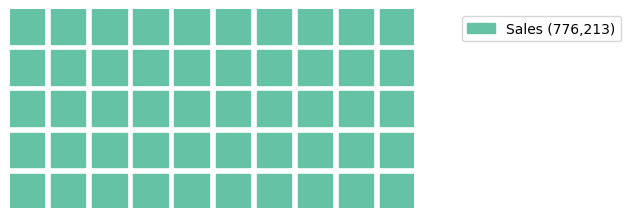

In [52]:
fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=10,
    values=flats_df6.trans_group_en.value_counts(),
    legend={
        'labels': [f"{k} ({format_num(v)})" for k, v in flats_df6.trans_group_en.value_counts().items()],
        'loc': 'upper left',
        'bbox_to_anchor': (1.1, 1)
    }
)
fig.savefig('transaction_group_composition.png')
plt.show()

In [53]:
flats_df6[flats_df6.trans_group_en == 'Gifts'][['meter_sale_price', 'procedure_area', 'actual_worth']].head()

,meter_sale_price,procedure_area,actual_worth


In [54]:
flats_df6[flats_df6.trans_group_en == 'Sales'][['meter_sale_price', 'procedure_area', 'actual_worth']].head()

,meter_sale_price,procedure_area,actual_worth
370,"11,953.35000",85.75000,"1,025,000.00000"
372,"7,436.33000",161.37000,"1,200,000.00000"
379,"22,983.56000",130.18000,"2,992,000.00000"
380,"26,641.55000",130.06000,"3,465,000.00000"
381,"27,621.73000",130.25000,"3,597,730.00000"


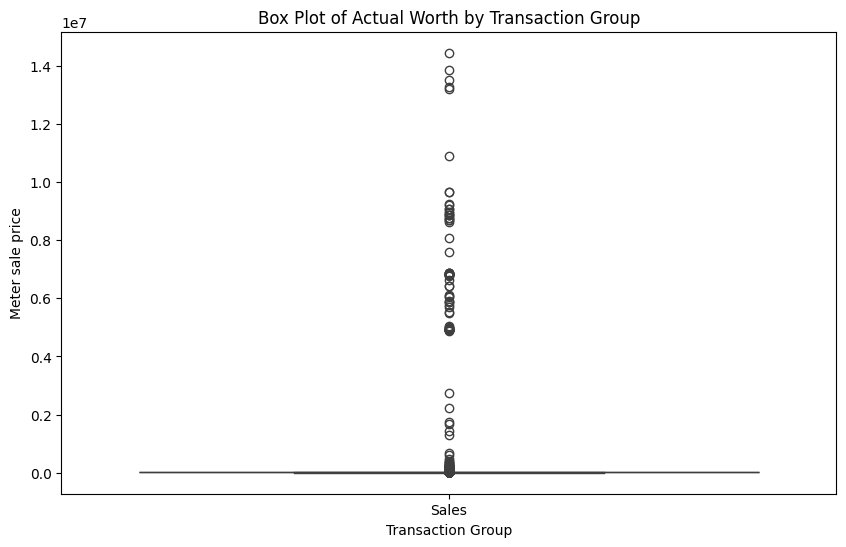

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=flats_df6, x='trans_group_en', y='meter_sale_price')
plt.title('Box Plot of Actual Worth by Transaction Group')
plt.xlabel('Transaction Group')
plt.ylabel('Meter sale price')
plt.show()

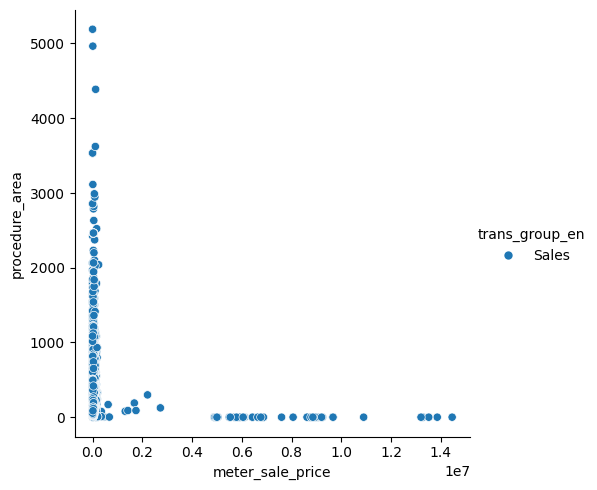

In [56]:
sns.relplot(data=flats_df6, x='meter_sale_price', y='procedure_area', hue='trans_group_en')

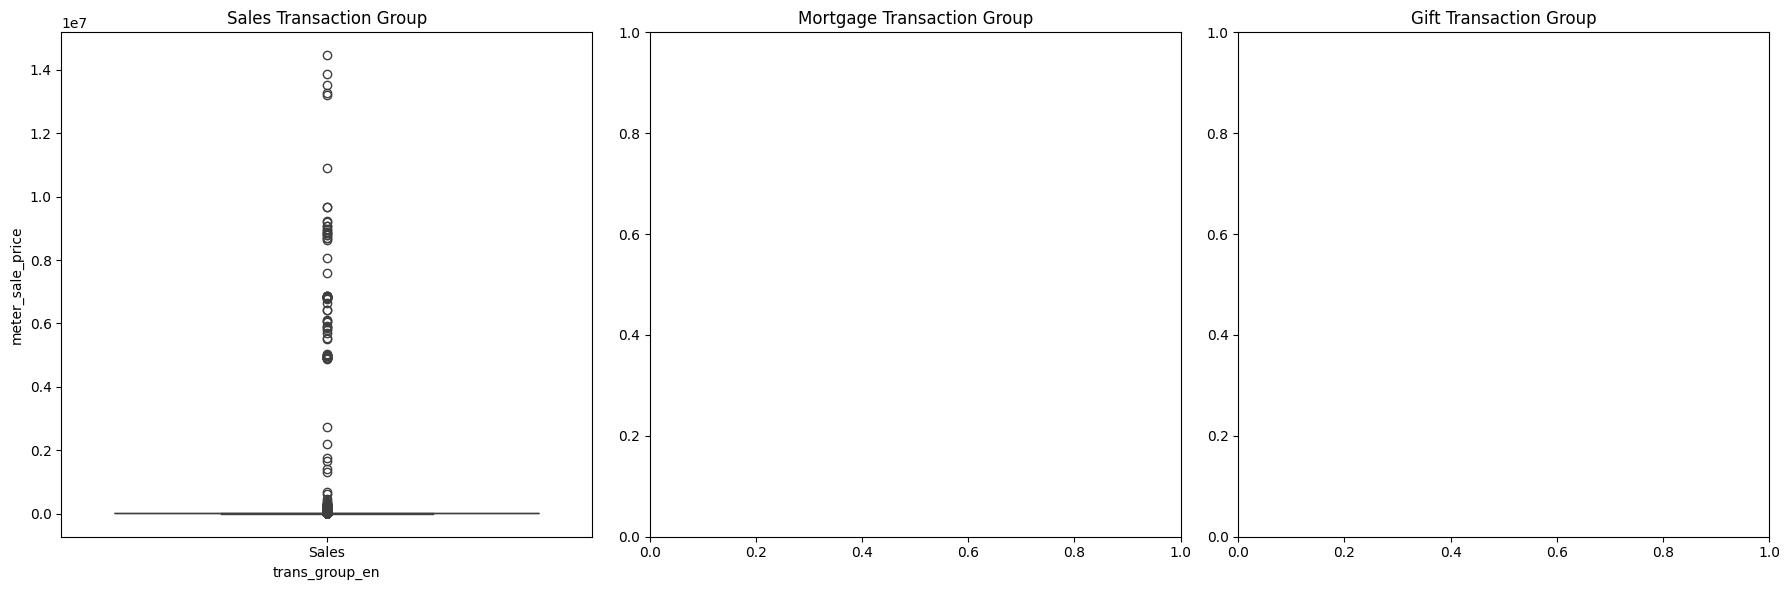

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sales_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Sales']
mortgage_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Mortgages']
gift_transaction_group = flats_df6[flats_df6['trans_group_en'] == 'Gifts']

sns.boxplot(
    data=sales_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[0]
)

sns.boxplot(
    data=mortgage_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[1]
)

sns.boxplot(
    data=gift_transaction_group,
    x='trans_group_en',
    y='meter_sale_price',
    ax=axes[2]
)

axes[0].set_title('Sales Transaction Group')
axes[1].set_title('Mortgage Transaction Group')
axes[2].set_title('Gift Transaction Group')

plt.tight_layout()
plt.show()

In [58]:
sales_transaction_group['meter_sale_price'].describe()

count      776,213.00000
mean        17,118.40965
std         71,272.48902
min              0.01000
25%         10,042.53000
50%         14,813.73000
75%         20,804.44000
max     14,453,900.00000
Name: meter_sale_price, dtype: float64

In [59]:
mortgage_transaction_group['meter_sale_price'].describe()

count   0.00000
mean        NaN
std         NaN
min         NaN
25%         NaN
50%         NaN
75%         NaN
max         NaN
Name: meter_sale_price, dtype: float64

In [60]:
gift_transaction_group['meter_sale_price'].describe()

count   0.00000
mean        NaN
std         NaN
min         NaN
25%         NaN
50%         NaN
75%         NaN
max         NaN
Name: meter_sale_price, dtype: float64

The mean sale price for:
1. Sale properties is 16,825.9
2. Mortgage properties is 13,982
3. Gift properties is 12,714.8

In [61]:
12714/16825

0.7556612184249628

In [62]:
sale_mean_price = sales_transaction_group['meter_sale_price'].mean()
gift_mean_price = gift_transaction_group['meter_sale_price'].mean()
percent = round(gift_mean_price / sale_mean_price, 2) * 100

print(f"Gift sale price on average are {percent}% of sale mean price")

Gift sale price on average are nan% of sale mean price


In [63]:
print(f"Total sales transactions: {len(sales_transaction_group)}")
print(f"Total gift transactions: {len(gift_transaction_group)}")

print(f"Sales tr percentage: {round(len(sales_transaction_group)/len(flats_df6), 2) * 100}")
print(f"Gift tr percentage: {round(len(gift_transaction_group)/len(flats_df6), 2) * 100}")

Total sales transactions: 776213
Total gift transactions: 0
Sales tr percentage: 100.0
Gift tr percentage: 0.0


In [64]:
# Since gift transactions are only 3 percent we, can remove them

/var/folders/j5/b_yzj8c173n5bygl1tcrnw840000gn/T/ipykernel_26175/1359685233.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


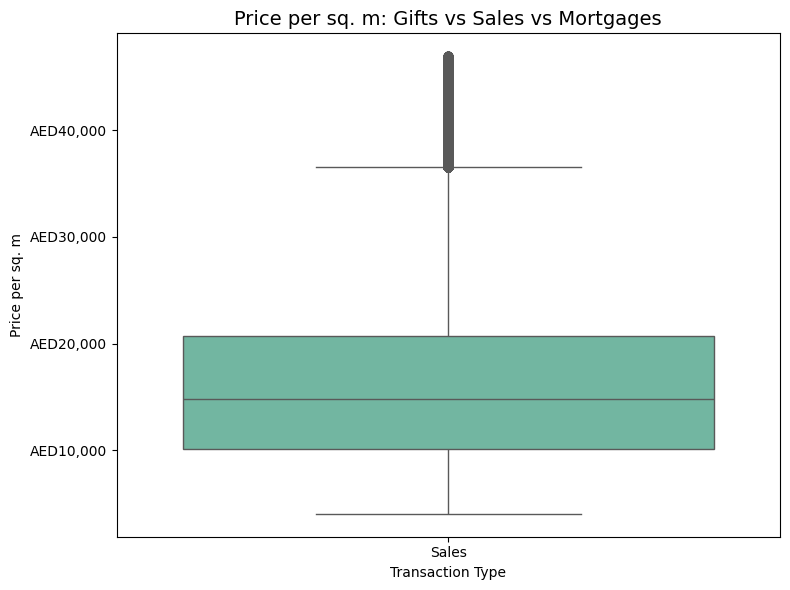

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

q_low = flats_df6['meter_sale_price'].quantile(0.01)
q_high = flats_df6['meter_sale_price'].quantile(0.99)
filtered_df = flats_df6[(flats_df6['meter_sale_price'] >= q_low) & (flats_df6['meter_sale_price'] <= q_high)]

plt.figure(figsize=(8,6))
sns.boxplot(
    x='trans_group_en',
    y='meter_sale_price',
    data=filtered_df,
    showfliers=True,
    palette="Set2"
)


import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('AED{x:,.0f}'))

plt.title("Price per sq. m: Gifts vs Sales vs Mortgages", fontsize=14)
plt.xlabel("Transaction Type")
plt.ylabel("Price per sq. m")

plt.tight_layout()
plt.show()


In [66]:
flats_df7 = flats_df6[flats_df6['trans_group_en'] != 'Gifts']
print(f"With gift transactions, total = {len(flats_df6)}")
print(f"Without gift transactions, total = {len(flats_df7)}")

With gift transactions, total = 776213
Without gift transactions, total = 776213


In [67]:
flats_df7 = flats_df7.drop(columns=['trans_group_id', 'trans_group_en'])

In [68]:
flats_df7.shape

(776213, 24)

In [69]:
print(f"{len(flats_df7)} Samples & {len(flats_df7.columns)} Features")

776213 Samples & 24 Features


In [70]:
# flats_df7[['trans_group_en', 'procedure_name_en']].head(10)

In [71]:
flats_df7.procedure_name_en.value_counts()

procedure_name_en
Sell - Pre registration    464877
Sell                       311336
Name: count, dtype: int64

In [72]:
flats_df7.head()

,procedure_id,procedure_name_en,reg_type_id,reg_type_en,area_id,area_name_en,building_name_en,project_number,project_name_en,master_project_en,...,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date
370,11,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 1,NaN,NaN,NaN,...,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,1.00000,1.00000,0.00000,2016-02-15
372,11,Sell,1,Existing Properties,255,Rega Al Buteen,EMAAR TOWER 2,NaN,NaN,NaN,...,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,1.00000,1.00000,0.00000,2018-05-01
379,102,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",VOLTA TOWER,NaN,...,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,1.00000,2.00000,0.00000,2024-01-16
380,102,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",VOLTA TOWER,NaN,...,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,1.00000,1.00000,0.00000,2024-05-07
381,102,Sell - Pre registration,0,Off-Plan Properties,390,Burj Khalifa,VOLTA TOWER,"2,782.00000",VOLTA TOWER,NaN,...,1,130.25000,"3,597,730.00000","27,621.73000",NaN,NaN,1.00000,2.00000,0.00000,2024-02-29


In [73]:
flats_df7.reg_type_en.value_counts()

reg_type_en
Off-Plan Properties    464877
Existing Properties    311336
Name: count, dtype: int64

In [74]:
# from sklearn.preprocessing import OneHotEncoder

In [75]:
# encoder = OneHotEncoder(sparse_output=False)
# encoded_reg_type = encoder.fit_transform(flats_df6[['reg_type_en']])

In [76]:
# print(encoded_reg_type)

In [77]:
# encoded_reg_type

In [78]:
# encoder.get_feature_names_out(['reg_type_en'])

In [79]:
# encoded_df = pd.DataFrame(encoded_reg_type, columns=encoder.get_feature_names_out(['reg_type_en']))
# encoded_df.head()

In [80]:
# flats_df7 = pd.concat([flats_df6.drop(columns=['reg_type_en', 'reg_type_id']), encoded_df], axis=1)

In [81]:
# flats_df7.head()
# len(flats_df7)

In [82]:
# area_names_df = flats_df7.area_name_en.value_counts().reset_index()
# area_names_df.shape

## Area name en and id

In [83]:
mapping_check = flats_df7.groupby('area_id')['area_name_en'].nunique()
type(mapping_check)

pandas.Series

In [84]:
print(f"No. of conflicts: {len(mapping_check[mapping_check > 1])}")

No. of conflicts: 0


In [85]:
flats_df8 = flats_df7.drop(columns=['area_id'])

In [86]:
flats_df8.shape
# flats_df8.head()

(776213, 23)

In [87]:
flats_df8.area_name_en.isna().sum()

np.int64(0)

In [88]:
def _clean_name(name):
  if pd.isna(name):
    return 'Unknown'
  return name.strip()

In [89]:
flats_df9 = flats_df8.drop(columns=['area_name_en'])
flats_df9['area_name_en'] = flats_df8['area_name_en'].apply(_clean_name)

In [90]:
flats_df9['area_name_en'].value_counts()

area_name_en
Marsa Dubai                    91287
Al Barsha South Fourth         72501
Business Bay                   52290
Burj Khalifa                   45397
Al Warsan First                40242
                               ...  
Um Hurair Second                  98
Al Qusais Industrial Fourth       97
Nad Al Hamar                      88
Al Qusais Industrial Fifth        72
Hessyan Second                     3
Name: count, Length: 71, dtype: int64

In [91]:
# area_name_en will use

`area_name_en` transformation will be done via OHE.

The project_number and project_name_en have a 1-1 mapping.

In [92]:
flats_df9 = flats_df9.drop(columns=['project_number'])

In [93]:
df_status(flats_df9)

776,213 Samples & 22 Features


In [94]:
flats_df9.columns

Index(['procedure_id', 'procedure_name_en', 'reg_type_id', 'reg_type_en',
       'building_name_en', 'project_name_en', 'master_project_en',
       'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en',
       'rooms_en', 'has_parking', 'procedure_area', 'actual_worth',
       'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date', 'area_name_en'],
      dtype='str')

In [95]:
flats_df9['project_name_en'].value_counts()

project_name_en
REMRAAM                          6643
SKY COURTS                       4355
INTERNATIONAL CITY EMARATI       3810
LAKESIDE                         3798
SEVEN CITY JLT                   3522
                                 ... 
THE ROYAL ESTATES PLOT.2            1
Amazonia                            1
RUFI PRIME VIEW                     1
AL FALAK RESIDENCE                  1
Barari Parkview by Al Mawared       1
Name: count, Length: 2126, dtype: int64

In [96]:
without_project_name = flats_df9['project_name_en'].isna().sum()

In [97]:
print(f"There are a total of {without_project_name} Transactions without project name")
print(f"This is about {round(without_project_name/len(flats_df9),2)*100}%")
print("This can't be dropped, we need to mark them as unknown")

There are a total of 131577 Transactions without project name
This is about 17.0%
This can't be dropped, we need to mark them as unknown


In [98]:
flats_df9.drop(columns=['procedure_id'], inplace=True, errors='ignore')

In [99]:
flats_df9.columns

Index(['procedure_name_en', 'reg_type_id', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'has_parking',
       'procedure_area', 'actual_worth', 'meter_sale_price', 'rent_value',
       'meter_rent_price', 'no_of_parties_role_1', 'no_of_parties_role_2',
       'no_of_parties_role_3', 'parsed_date', 'area_name_en'],
      dtype='str')

## Area Name

In [100]:
flats_df9.area_name_en.nunique()

71

In [101]:
print(f"Missing area names in data: {flats_df9.area_name_en.isna().sum()}")


Missing area names in data: 0


## Building Name

# Categorical Features


In [102]:
flats_df9.select_dtypes(include=['str']).columns

Index(['procedure_name_en', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'area_name_en'],
      dtype='str')

In [103]:
flats_df9.rooms_en.value_counts()

rooms_en
1 B/R          328796
2 B/R          199744
Studio         176227
3 B/R           60375
4 B/R            8102
5 B/R             969
PENTHOUSE         959
Single Room       682
6 B/R              86
Shop               26
7 B/R               5
9 B/R               3
8 B/R               2
Office              2
Name: count, dtype: int64

In [104]:
room_map = {
    '1 B/R': 1,
    '2 B/R': 2,
    '3 B/R': 3,
    '4 B/R': 4,
    '5 B/R': 5,
    '6 B/R': 6,
    '7 B/R': 7,
    '8 B/R': 8,
    '9 B/R': 9,
    'Studio': 1,
    'Penthouse': 5,
    'Single Room': 1,
    'Shop': -1,
    'Office': -1,
}
flats_df9['rooms_num'] = flats_df9.rooms_en.map(room_map)

In [105]:
flats_df9['rooms_num'].describe()
flats_df9.shape

(776213, 22)

In [106]:
flats_df9.columns

Index(['procedure_name_en', 'reg_type_id', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'has_parking',
       'procedure_area', 'actual_worth', 'meter_sale_price', 'rent_value',
       'meter_rent_price', 'no_of_parties_role_1', 'no_of_parties_role_2',
       'no_of_parties_role_3', 'parsed_date', 'area_name_en', 'rooms_num'],
      dtype='str')

In [107]:
flats_df10 = flats_df9.drop(columns=['rooms_en'])

In [108]:
flats_df10.columns

Index(['procedure_name_en', 'reg_type_id', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date', 'area_name_en', 'rooms_num'],
      dtype='str')

In [109]:
(flats_df10.rooms_num == -1).sum()

np.int64(28)

In [110]:
flats_df10[flats_df10.rooms_num == -1].head()

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,...,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date,area_name_en,rooms_num
53113,Sell,1,Existing Properties,MARINA DIAMOND - B,NaN,Dubai Marina,Burj Al Arab,Dubai Marina,Marina Mall,1,...,"800,000.00000","11,374.95000",NaN,NaN,1.00000,2.00000,0.00000,2023-02-21,Marsa Dubai,-1.00000
76571,Sell,1,Existing Properties,MARINA DIAMOND-3,NaN,Dubai Marina,Burj Al Arab,Dubai Marina,Marina Mall,1,...,"5,070,800.00000","30,138.48000",NaN,NaN,6.00000,1.00000,0.00000,2008-07-22,Marsa Dubai,-1.00000
78279,Sell,1,Existing Properties,ALNAKHEEL 1,NaN,The Greens,Burj Al Arab,Dubai Internet City,Marina Mall,0,...,"1,200,000.00000","7,796.76000",NaN,NaN,2.00000,1.00000,0.00000,2012-01-18,Al Thanyah Third,-1.00000
129791,Sell,1,Existing Properties,NAKHEEL 2,NaN,The Greens,Burj Al Arab,Dubai Internet City,Marina Mall,0,...,"544,800.00000","4,068.10000",NaN,NaN,1.00000,1.00000,0.00000,2013-03-18,Al Thanyah Third,-1.00000
181344,Sell,1,Existing Properties,ALNAKHEEL 4,NaN,The Greens,Burj Al Arab,Dubai Internet City,Marina Mall,0,...,"1,000,000.00000","15,825.29000",NaN,NaN,1.00000,1.00000,0.00000,2016-03-30,Al Thanyah Third,-1.00000


In [111]:
# Drop samples with rooms_num = -1
flats_df11 = flats_df10[flats_df10.rooms_num != -1]


In [112]:
df_status(flats_df10)
df_status(flats_df11)

776,213 Samples & 21 Features
776,185 Samples & 21 Features


In [113]:
building_counts = flats_df11.building_name_en.value_counts()
building_counts

building_name_en
Seven City JLT               3522
PRINCESS TOWER               2318
Marina Pinnacle              2119
ELITE RESIDENCE              2098
Torch Tower                  1988
                             ... 
AMBER                           1
The Cape - B                    1
Frond/JHFTD                     1
The Palm Hotel and Resort       1
Frond/JHFTA                     1
Name: count, Length: 4284, dtype: int64

No. of unique buildings: 4284
<class 'pandas.Series'>
count   4,284.00000
mean      181.18231
std       216.78491
min         1.00000
25%        48.00000
50%       118.00000
75%       230.00000
max     3,522.00000
Name: count, dtype: float64


Text(0, 0.5, 'Frequency of transactions for those buildings')

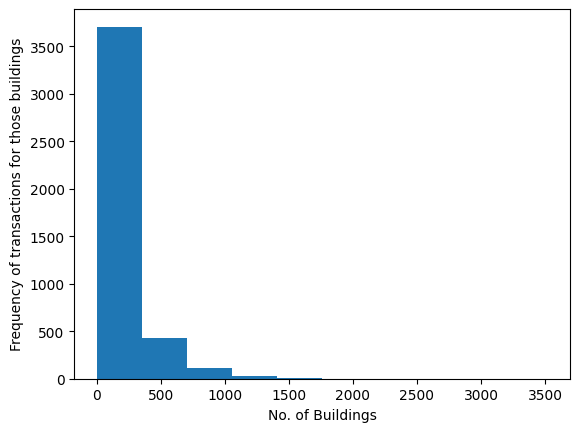

In [114]:
print(f"No. of unique buildings: {len(building_counts)}")
print(type(building_counts))
print(building_counts.describe())
plt.hist(building_counts)
plt.xlabel('No. of Buildings')
plt.ylabel('Frequency of transactions for those buildings')

In [115]:
mean_count = building_counts.mean()
print(f"Mean count: {round(mean_count, 2)}")

Mean count: 181.18


In [116]:
flats_df11.building_name_en.isna().sum()

np.int64(0)

In [117]:
# no_trans_group_transactions = len(flats_df11[flats_df11.trans_group_en.isna()])
# transactions_with_trans_group = len(flats_df11[~flats_df11.trans_group_en.isna()])
# print(f"Rows with trans_group_en is null : {no_trans_group_transactions}")
# print(f"Rows with trans_group_en is not null : {transactions_with_trans_group}")
# print(f"Percentage of rows with trans_group_en is null : {round((no_trans_group_transactions / len(flats_df10)) * 100, 2)}%")

In [118]:
df_status(flats_df11)

776,185 Samples & 21 Features


# Non Categorical Columns

In [119]:
non_categorical_columns = flats_df11.select_dtypes(exclude=['str']).columns

In [120]:
non_categorical_columns

Index(['reg_type_id', 'has_parking', 'procedure_area', 'actual_worth',
       'meter_sale_price', 'rent_value', 'meter_rent_price',
       'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3',
       'parsed_date', 'rooms_num'],
      dtype='str')

In [121]:
flats_df11.reg_type_id.value_counts()

reg_type_id
0    464877
1    311308
Name: count, dtype: int64

In [122]:
flats_df11.reg_type_id.isna().sum()

np.int64(0)

In [123]:
flats_df11.reg_type_en.value_counts()

reg_type_en
Off-Plan Properties    464877
Existing Properties    311308
Name: count, dtype: int64

In [124]:
flats_df12 = flats_df11.drop(columns=['reg_type_en'])
## Since both reg_type_en and reg_type_id represent same thing,
## we drop reg_type_id
df_status(flats_df12)

776,185 Samples & 20 Features


In [125]:
flats_df12.has_parking.value_counts()

has_parking
1    723854
0     52331
Name: count, dtype: int64

In [126]:
flats_df12[['procedure_area', 'meter_sale_price', 'actual_worth']]

,procedure_area,meter_sale_price,actual_worth
370,85.75000,"11,953.35000","1,025,000.00000"
372,161.37000,"7,436.33000","1,200,000.00000"
379,130.18000,"22,983.56000","2,992,000.00000"
380,130.06000,"26,641.55000","3,465,000.00000"
381,130.25000,"27,621.73000","3,597,730.00000"
...,...,...,...
1665082,134.76000,"24,783.97000","3,339,888.00000"
1665083,68.45000,"27,142.26000","1,857,888.00000"
1665084,115.98000,"37,402.03000","4,337,888.00000"
1665104,53.49000,"4,544.79000","243,101.00000"


In [127]:
flats_df11.actual_worth.value_counts()
# actual_worth is the y
# meter_sale_price is correlated with actual_worth inversely; should be dropped
# flats_df12 = flats_df11.drop(columns=['meter_sale_price'])

actual_worth
1,000,000.00000    3967
500,000.00000      3819
1,200,000.00000    3675
600,000.00000      3326
1,100,000.00000    3319
                   ... 
986,140.00000         1
1,115,097.00000       1
1,577,732.00000       1
1,171,224.00000       1
1,369,605.00000       1
Name: count, Length: 192861, dtype: int64

In [128]:
flats_df11.shape

(776185, 21)

### Dropping meter_rent_price
Taking assumption that won't be available in final testing, so dropping the feature

DROPPING LATER. BECAUSE OF SOME DEBUGGING

In [129]:
# flats_df12 = flats_df11.drop(columns=['meter_rent_price', 'rent_value'])
flats_df12 = flats_df11

In [130]:
flats_df12.head()

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,...,actual_worth,meter_sale_price,rent_value,meter_rent_price,no_of_parties_role_1,no_of_parties_role_2,no_of_parties_role_3,parsed_date,area_name_en,rooms_num
370,Sell,1,Existing Properties,EMAAR TOWER 1,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,...,"1,025,000.00000","11,953.35000",NaN,NaN,1.00000,1.00000,0.00000,2016-02-15,Rega Al Buteen,1.00000
372,Sell,1,Existing Properties,EMAAR TOWER 2,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,...,"1,200,000.00000","7,436.33000",NaN,NaN,1.00000,1.00000,0.00000,2018-05-01,Rega Al Buteen,3.00000
379,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,...,"2,992,000.00000","22,983.56000",NaN,NaN,1.00000,2.00000,0.00000,2024-01-16,Burj Khalifa,2.00000
380,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,...,"3,465,000.00000","26,641.55000",NaN,NaN,1.00000,1.00000,0.00000,2024-05-07,Burj Khalifa,2.00000
381,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,...,"3,597,730.00000","27,621.73000",NaN,NaN,1.00000,2.00000,0.00000,2024-02-29,Burj Khalifa,2.00000


## Drop number of parties for registration



In [131]:
flats_df13 = flats_df12.drop(columns=['no_of_parties_role_1','no_of_parties_role_2', 'no_of_parties_role_3'])
df_status(flats_df13)

776,185 Samples & 18 Features


# Final Number of Features before any encoding is 15 including target variable

In [132]:
flats_df13.head()

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num
370,Sell,1,Existing Properties,EMAAR TOWER 1,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,2016-02-15,Rega Al Buteen,1.00000
372,Sell,1,Existing Properties,EMAAR TOWER 2,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,2018-05-01,Rega Al Buteen,3.00000
379,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,2024-01-16,Burj Khalifa,2.00000
380,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,2024-05-07,Burj Khalifa,2.00000
381,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.25000,"3,597,730.00000","27,621.73000",NaN,NaN,2024-02-29,Burj Khalifa,2.00000


# Check Target Variable

In [133]:
flats_df13.actual_worth.describe()

count       776,185.00000
mean      1,666,187.59865
std       3,093,393.26719
min               1.00000
25%         673,000.00000
50%       1,129,888.00000
75%       1,912,888.00000
max     659,741,940.00000
Name: actual_worth, dtype: float64

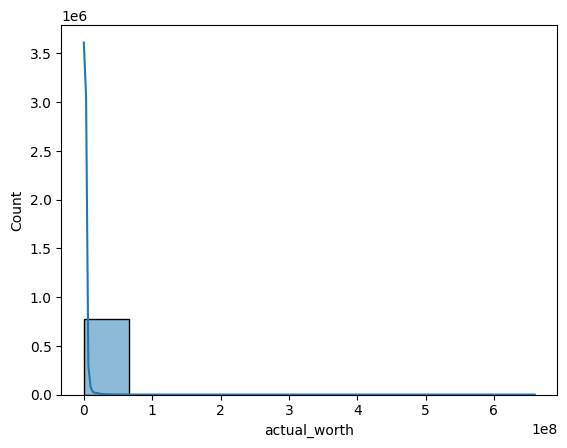

In [134]:
sns.histplot(flats_df13['actual_worth'], bins=10, kde=True)
plt.show()

In [135]:
skewness = flats_df13['actual_worth'].skew()
print(f"Skewness: {skewness:.2f}")


Skewness: 49.00


In [136]:
low_priced_transactions = flats_df13[flats_df13['actual_worth'] < 300000][['actual_worth', 'meter_sale_price', 'parsed_date']].sort_values(by='parsed_date')

In [137]:
print(f"Total transactions lower than 300k: {len(low_priced_transactions)}")

Total transactions lower than 300k: 24787


In [138]:
MAX_ACTUAL_WORTH = flats_df13.actual_worth.quantile(0.99)
high_priced_transactions =  flats_df13[flats_df13['actual_worth']>MAX_ACTUAL_WORTH]

In [139]:
print(f"Total transactions greater than 99 quantile: {len(high_priced_transactions)}")

Total transactions greater than 99 quantile: 7762


In [140]:
# Remove low priced transactions
flats_df14 = flats_df13[flats_df13['actual_worth'] > 300000]

In [141]:
df_status(flats_df13)
df_status(flats_df14)

776,185 Samples & 18 Features
749,153 Samples & 18 Features


In [142]:
flats_df15 = flats_df14[flats_df14['actual_worth'] < MAX_ACTUAL_WORTH]

In [143]:
df_status(flats_df14)
df_status(flats_df15)

749,153 Samples & 18 Features
741,391 Samples & 18 Features


In [144]:
flats_df15['actual_worth_log'] = np.log1p(flats_df15['actual_worth'])
flats_df15.head()

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log
370,Sell,1,Existing Properties,EMAAR TOWER 1,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,2016-02-15,Rega Al Buteen,1.00000,13.84020
372,Sell,1,Existing Properties,EMAAR TOWER 2,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,2018-05-01,Rega Al Buteen,3.00000,13.99783
379,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,2024-01-16,Burj Khalifa,2.00000,14.91145
380,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,2024-05-07,Burj Khalifa,2.00000,15.05822
381,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.25000,"3,597,730.00000","27,621.73000",NaN,NaN,2024-02-29,Burj Khalifa,2.00000,15.09581


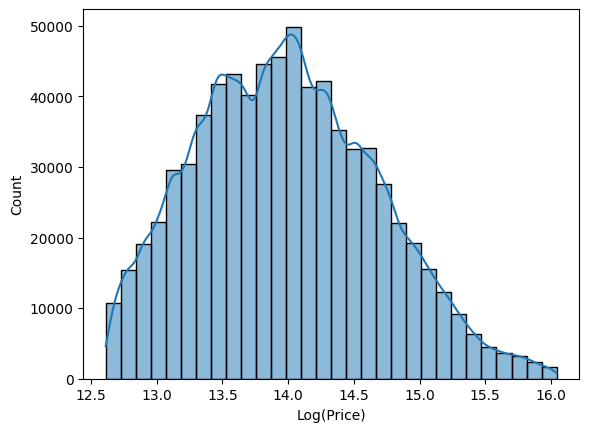

In [145]:
sns.histplot(flats_df15['actual_worth_log'], bins=30, kde=True)
plt.xlabel("Log(Price)")
plt.show()

In [146]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()

In [147]:
# flats_df14['actual_worth_scaled'] = scaler.fit_transform(
#     flats_df14[['actual_worth_log']]
# )
# flats_df14.head()

In [148]:
# flats_df14.actual_worth_scaled.describe()

In [149]:
# import joblib

# joblib.dump(scaler, 'actual_worth_log_scaler.pkl')

In [150]:
# import joblib

# # Load the scaler
# scaler = joblib.load('scaler.pkl')

# # Inverse transform
# original_log_values = scaler.inverse_transform(flats_df14[['actual_worth_scaled']])
# original_values = np.expm1(original_log_values)


In [151]:
flats_df15['actual_worth_non_log'] = np.expm1(flats_df15['actual_worth_log'])
flats_df15.head()

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log,actual_worth_non_log
370,Sell,1,Existing Properties,EMAAR TOWER 1,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,2016-02-15,Rega Al Buteen,1.00000,13.84020,"1,025,000.00000"
372,Sell,1,Existing Properties,EMAAR TOWER 2,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,2018-05-01,Rega Al Buteen,3.00000,13.99783,"1,200,000.00000"
379,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,2024-01-16,Burj Khalifa,2.00000,14.91145,"2,992,000.00000"
380,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,2024-05-07,Burj Khalifa,2.00000,15.05822,"3,465,000.00000"
381,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.25000,"3,597,730.00000","27,621.73000",NaN,NaN,2024-02-29,Burj Khalifa,2.00000,15.09581,"3,597,730.00000"


In [152]:
flats_df16 = flats_df15.drop(columns=['actual_worth_non_log'])

In [153]:
flats_df16.head()


,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log
370,Sell,1,Existing Properties,EMAAR TOWER 1,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,85.75000,"1,025,000.00000","11,953.35000",NaN,NaN,2016-02-15,Rega Al Buteen,1.00000,13.84020
372,Sell,1,Existing Properties,EMAAR TOWER 2,NaN,NaN,Dubai International Airport,Al Rigga Metro Station,Dubai Mall,1,161.37000,"1,200,000.00000","7,436.33000",NaN,NaN,2018-05-01,Rega Al Buteen,3.00000,13.99783
379,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.18000,"2,992,000.00000","22,983.56000",NaN,NaN,2024-01-16,Burj Khalifa,2.00000,14.91145
380,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.06000,"3,465,000.00000","26,641.55000",NaN,NaN,2024-05-07,Burj Khalifa,2.00000,15.05822
381,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,NaN,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.25000,"3,597,730.00000","27,621.73000",NaN,NaN,2024-02-29,Burj Khalifa,2.00000,15.09581


# Feature Columns

## Handling Null Values

In [154]:
flats_df16.columns

Index(['procedure_name_en', 'reg_type_id', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'parsed_date', 'area_name_en', 'rooms_num', 'actual_worth_log'],
      dtype='str')

In [155]:
flats_df16.isnull().mean() * 100

procedure_name_en       0.00000
reg_type_id             0.00000
reg_type_en             0.00000
building_name_en        0.00000
project_name_en        15.45514
master_project_en       6.50305
nearest_landmark_en    17.64292
nearest_metro_en       23.93420
nearest_mall_en        24.55573
has_parking             0.00000
procedure_area          0.00000
actual_worth            0.00000
meter_sale_price        0.00000
rent_value            100.00000
meter_rent_price      100.00000
parsed_date             0.00000
area_name_en            0.00000
rooms_num               0.14729
actual_worth_log        0.00000
dtype: float64

In [156]:
flats_df16.columns

Index(['procedure_name_en', 'reg_type_id', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price',
       'parsed_date', 'area_name_en', 'rooms_num', 'actual_worth_log'],
      dtype='str')

In [157]:
flats_df16[flats_df16.master_project_en == 'Dubai Marina'].head(20)

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log
560,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,70.08000,"406,169.00000","5,795.79000",NaN,NaN,2007-10-04,Marsa Dubai,1.00000,12.91453
561,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,83.59000,"484,469.00000","5,795.78000",NaN,NaN,2007-10-01,Marsa Dubai,1.00000,13.09081
562,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,125.14000,"1,270,000.00000","10,148.63000",NaN,NaN,2021-06-24,Marsa Dubai,2.00000,14.05453
563,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,69.67000,"1,300,000.00000","18,659.39000",NaN,NaN,2008-11-03,Marsa Dubai,1.00000,14.07788
565,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,135.35000,"784,463.00000","5,795.81000",NaN,NaN,2007-08-23,Marsa Dubai,2.00000,13.57276
566,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,449.10000,"4,800,000.00000","10,688.04000",NaN,NaN,2020-11-19,Marsa Dubai,4.00000,15.38413
567,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,201.93000,"2,600,000.00000","12,875.75000",NaN,NaN,2013-09-30,Marsa Dubai,3.00000,14.77102
569,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,159.25000,"922,983.00000","5,795.81000",NaN,NaN,2007-10-04,Marsa Dubai,2.00000,13.73537
570,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,131.13000,"760,001.00000","5,795.78000",NaN,NaN,2007-10-01,Marsa Dubai,2.00000,13.54108
571,Sell,1,Existing Properties,MARINA CROWN TOWER,NaN,Dubai Marina,Burj Al Arab,Mina Seyahi,Marina Mall,1,78.29000,"600,000.00000","7,663.81000",NaN,NaN,2011-07-18,Marsa Dubai,1.00000,13.30469


In [158]:
flats_df16.project_name_en.value_counts()

project_name_en
REMRAAM                          6418
SKY COURTS                       3782
SEVEN CITY JLT                   3517
LAKESIDE                         3243
INTERNATIONAL CITY EMARATI       3237
                                 ... 
Amazonia                            1
RUFI PRIME VIEW                     1
AL FALAK RESIDENCE                  1
Barari Parkview by Al Mawared       1
THE S TOWER                         1
Name: count, Length: 2090, dtype: int64

In [159]:
flats_df16[flats_df16.building_name_en == 'Seven City JLT'].head(10)

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,rent_value,meter_rent_price,parsed_date,area_name_en,rooms_num,actual_worth_log
24408,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,64.42000,"704,617.00000","10,937.86000",NaN,NaN,2023-01-30,Al Thanyah Fifth,1.00000,13.46541
24409,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,38.59000,"464,497.00000","12,036.72000",NaN,NaN,2023-01-09,Al Thanyah Fifth,1.00000,13.04871
24410,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,140.91000,"1,389,097.00000","9,858.04000",NaN,NaN,2022-12-15,Al Thanyah Fifth,3.00000,14.14417
24411,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,38.59000,"450,697.00000","11,679.11000",NaN,NaN,2022-11-15,Al Thanyah Fifth,1.00000,13.01855
24412,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,38.58000,"530,000.00000","13,737.69000",NaN,NaN,2024-04-04,Al Thanyah Fifth,1.00000,13.18063
24413,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,71.97000,"734,057.00000","10,199.49000",NaN,NaN,2021-06-15,Al Thanyah Fifth,1.00000,13.50634
24414,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,141.23000,"1,661,547.00000","11,764.84000",NaN,NaN,2023-07-19,Al Thanyah Fifth,3.00000,14.32326
24415,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,38.59000,"384,227.00000","9,956.65000",NaN,NaN,2019-10-30,Al Thanyah Fifth,1.00000,12.85899
24416,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,38.59000,"384,227.00000","9,956.65000",NaN,NaN,2019-01-09,Al Thanyah Fifth,1.00000,12.85899
24417,Sell - Pre registration,0,Off-Plan Properties,Seven City JLT,SEVEN CITY JLT,Jumeirah Islands,Burj Al Arab,Damac Properties,Marina Mall,1,71.97000,"722,081.00000","10,033.08000",NaN,NaN,2021-09-08,Al Thanyah Fifth,1.00000,13.48989


In [160]:
flats_df16[['building_name_en', 'project_name_en', 'master_project_en']]

,building_name_en,project_name_en,master_project_en
370,EMAAR TOWER 1,NaN,NaN
372,EMAAR TOWER 2,NaN,NaN
379,VOLTA TOWER,VOLTA TOWER,NaN
380,VOLTA TOWER,VOLTA TOWER,NaN
381,VOLTA TOWER,VOLTA TOWER,NaN
...,...,...,...
1665081,Creek Bay Tower A,Creek Bay,Dubai Creek Harbour
1665082,Creek Bay Tower A,Creek Bay,Dubai Creek Harbour
1665083,Creek Bay Tower A,Creek Bay,Dubai Creek Harbour
1665084,Creek Bay Tower A,Creek Bay,Dubai Creek Harbour


In [161]:
# Handle missing  project name

flats_df16[flats_df16.master_project_en.isna() & flats_df16.project_name_en.isna()]
flats_df17 = flats_df16.copy()
flats_df17['project_name_en'] = flats_df16['project_name_en'].fillna(flats_df16['building_name_en'])

In [162]:
flats_df17.project_name_en.isna().sum()

np.int64(0)

In [163]:
flats_df18 = flats_df17.copy()
flats_df18['master_project_en'] = flats_df17['master_project_en'].fillna(flats_df17['project_name_en'])

In [164]:
flats_df18.isna().sum()

procedure_name_en           0
reg_type_id                 0
reg_type_en                 0
building_name_en            0
project_name_en             0
master_project_en           0
nearest_landmark_en    130803
nearest_metro_en       177446
nearest_mall_en        182054
has_parking                 0
procedure_area              0
actual_worth                0
meter_sale_price            0
rent_value             741391
meter_rent_price       741391
parsed_date                 0
area_name_en                0
rooms_num                1092
actual_worth_log            0
dtype: int64

In [165]:
flats_df18.nearest_landmark_en.value_counts()

nearest_landmark_en
Sports City Swimming Academy         172067
Burj Al Arab                         127852
Downtown Dubai                       107597
Motor City                            63415
IMG World Adventures                  42119
Burj Khalifa                          41919
Dubai International Airport           26903
Expo 2020 Site                        16019
Dubai Cycling Course                   7028
Al Makhtoum International Airport      2040
Global Village                         2038
Dubai Parks and Resorts                1589
Jabel Ali                                 2
Name: count, dtype: int64

In [166]:
flats_df18['nearest_landmark_en'] = flats_df18.nearest_landmark_en.fillna('__MISSING__')

In [167]:
flats_df18.isna().mean() * 100

procedure_name_en       0.00000
reg_type_id             0.00000
reg_type_en             0.00000
building_name_en        0.00000
project_name_en         0.00000
master_project_en       0.00000
nearest_landmark_en     0.00000
nearest_metro_en       23.93420
nearest_mall_en        24.55573
has_parking             0.00000
procedure_area          0.00000
actual_worth            0.00000
meter_sale_price        0.00000
rent_value            100.00000
meter_rent_price      100.00000
parsed_date             0.00000
area_name_en            0.00000
rooms_num               0.14729
actual_worth_log        0.00000
dtype: float64

In [168]:
flats_df18['nearest_landmark_en'] = flats_df18.nearest_landmark_en.fillna('__MISSING__')
flats_df18['nearest_metro_en'] = flats_df18.nearest_metro_en.fillna('__MISSING__')
flats_df18['nearest_mall_en'] = flats_df18.nearest_mall_en.fillna('__MISSING__')


In [169]:
flats_df18.isna().mean() * 100

procedure_name_en       0.00000
reg_type_id             0.00000
reg_type_en             0.00000
building_name_en        0.00000
project_name_en         0.00000
master_project_en       0.00000
nearest_landmark_en     0.00000
nearest_metro_en        0.00000
nearest_mall_en         0.00000
has_parking             0.00000
procedure_area          0.00000
actual_worth            0.00000
meter_sale_price        0.00000
rent_value            100.00000
meter_rent_price      100.00000
parsed_date             0.00000
area_name_en            0.00000
rooms_num               0.14729
actual_worth_log        0.00000
dtype: float64

In [170]:
flats_df19 = flats_df18.drop(columns=['rent_value', 'meter_rent_price'])
flats_df19.isna().mean() * 100

procedure_name_en     0.00000
reg_type_id           0.00000
reg_type_en           0.00000
building_name_en      0.00000
project_name_en       0.00000
master_project_en     0.00000
nearest_landmark_en   0.00000
nearest_metro_en      0.00000
nearest_mall_en       0.00000
has_parking           0.00000
procedure_area        0.00000
actual_worth          0.00000
meter_sale_price      0.00000
parsed_date           0.00000
area_name_en          0.00000
rooms_num             0.14729
actual_worth_log      0.00000
dtype: float64

In [171]:
flats_df20 = flats_df19[~flats_df19['rooms_num'].isna()]
df_status(flats_df19)
df_status(flats_df20)

741,391 Samples & 17 Features
740,299 Samples & 17 Features


In [172]:
flats_df20[flats_df20.rooms_num.isna()].head(10)

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log


## Normalization for features

In [173]:
numerical_columns = flats_df20.select_dtypes(exclude=['str']).columns
numerical_columns

Index(['reg_type_id', 'has_parking', 'procedure_area', 'actual_worth',
       'meter_sale_price', 'parsed_date', 'rooms_num', 'actual_worth_log'],
      dtype='str')

In [174]:
# reg_type_id and has_parking are fine.

In [175]:
flats_df20.procedure_area.value_counts()

procedure_area
45.00000     3543
68.00000     2774
67.00000     2416
69.00000     1894
35.30000     1514
             ... 
267.61000       1
265.65000       1
360.86000       1
244.64000       1
176.42000       1
Name: count, Length: 23354, dtype: int64

In [176]:
flats_df20.procedure_area.skew()

np.float64(3.9524114344859482)

In [177]:
flats_df20.procedure_area.describe()

count   740,299.00000
mean         92.39594
std          55.88868
min           0.09000
25%          58.49000
50%          77.79000
75%         115.16000
max       3,532.64000
Name: procedure_area, dtype: float64

In [178]:
flats_df20.procedure_area.quantile(0.8)
flats_df21 = flats_df20[(flats_df20.procedure_area < flats_df20.procedure_area.quantile(0.99)) &
                        (flats_df20.procedure_area > flats_df20.procedure_area.quantile(0.001))]
flats_df21.procedure_area.skew()

np.float64(1.1665806072503209)

In [179]:
# flats_df22 = flats_df21.drop(columns=['rooms_en'])
# len(flats_df22)

## Handle Date

In [180]:
flats_df21.parsed_date.describe()

count                        732127
mean     2020-08-17 10:51:25.795770
min             2003-06-02 00:00:00
25%             2016-05-16 00:00:00
50%             2023-03-07 00:00:00
75%             2024-12-06 00:00:00
max             2026-02-17 00:00:00
Name: parsed_date, dtype: object

In [181]:
flats_df21 = flats_df21[flats_df21.parsed_date >= '2023-06-01']
df_status(flats_df21)

348,410 Samples & 17 Features


In [182]:
flats_df21.parsed_date.min()

Timestamp('2023-06-01 00:00:00')

In [183]:
reference_date = flats_df21.parsed_date.min()
flats_df21['days_since_reference_date'] = (flats_df21.parsed_date - reference_date).dt.days
flats_df21[['parsed_date', 'days_since_reference_date']]
# flats_df22 = flats_df21.drop(columns=['parsed_date'])
# len(flats_df22)

,parsed_date,days_since_reference_date
379,2024-01-16,229
380,2024-05-07,341
381,2024-02-29,273
382,2023-11-02,154
383,2025-05-14,713
...,...,...
1665081,2026-02-16,991
1665082,2026-01-09,953
1665083,2026-01-14,958
1665084,2026-01-20,964


In [184]:
flats_df21.days_since_reference_date.skew()

np.float64(-0.2725051930359009)

In [185]:
# flats_df21.head()
# flats_df22 = flats_df21.drop(columns='parsed_date')
flats_df22 = flats_df21
df_status(flats_df22)

348,410 Samples & 18 Features


In [186]:
flats_df22['days_since_reference_date'].describe()

count   348,410.00000
mean        559.32913
std         276.35649
min           0.00000
25%         344.00000
50%         578.00000
75%         804.00000
max         992.00000
Name: days_since_reference_date, dtype: float64

In [187]:
numerical_columns = flats_df18.select_dtypes(exclude=['object']).columns
numerical_columns

Index(['reg_type_id', 'has_parking', 'procedure_area', 'actual_worth',
       'meter_sale_price', 'rent_value', 'meter_rent_price', 'parsed_date',
       'rooms_num', 'actual_worth_log'],
      dtype='str')

In [188]:
flats_df22.procedure_area.describe()
# flats_df18.skew()

count   348,410.00000
mean         83.27154
std          40.98393
min          27.44000
25%          52.63000
50%          74.01000
75%         105.45000
max         280.77000
Name: procedure_area, dtype: float64

In [189]:
# flats_df22.procedure_area.skew()
# flats_df18['procedure_area_log'] = np.log1p(flats_df18['procedure_area'])

In [190]:
# flats_df19 = flats_df18.drop(columns=['procedure_area'])

In [191]:
flats_df22.days_since_reference_date.describe()

count   348,410.00000
mean        559.32913
std         276.35649
min           0.00000
25%         344.00000
50%         578.00000
75%         804.00000
max         992.00000
Name: days_since_reference_date, dtype: float64

In [192]:
flats_df22.days_since_reference_date.skew()

np.float64(-0.2725051930359009)

In [193]:
flats_df22.isna().sum()

procedure_name_en            0
reg_type_id                  0
reg_type_en                  0
building_name_en             0
project_name_en              0
master_project_en            0
nearest_landmark_en          0
nearest_metro_en             0
nearest_mall_en              0
has_parking                  0
procedure_area               0
actual_worth                 0
meter_sale_price             0
parsed_date                  0
area_name_en                 0
rooms_num                    0
actual_worth_log             0
days_since_reference_date    0
dtype: int64

In [194]:
flats_df22.info()

<class 'pandas.DataFrame'>
Index: 348410 entries, 379 to 1665107
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   procedure_name_en          348410 non-null  str           
 1   reg_type_id                348410 non-null  int64         
 2   reg_type_en                348410 non-null  str           
 3   building_name_en           348410 non-null  str           
 4   project_name_en            348410 non-null  str           
 5   master_project_en          348410 non-null  str           
 6   nearest_landmark_en        348410 non-null  str           
 7   nearest_metro_en           348410 non-null  str           
 8   nearest_mall_en            348410 non-null  str           
 9   has_parking                348410 non-null  int64         
 10  procedure_area             348410 non-null  float64       
 11  actual_worth               348410 non-null  float64       
 12  m

In [195]:
flats_df23 = flats_df22.copy()

In [196]:
# flats_df23 = flats_df22.drop(columns='meter_sale_price')

In [197]:
df_status(flats_df23)

348,410 Samples & 18 Features


In [198]:
categorical_columns = flats_df23.select_dtypes(include=['str']).columns
for col in categorical_columns:
    print(f"Unique counts of {col} is {flats_df23[col].nunique()}")

Unique counts of procedure_name_en is 2
Unique counts of reg_type_en is 2
Unique counts of building_name_en is 3929
Unique counts of project_name_en is 2847
Unique counts of master_project_en is 211
Unique counts of nearest_landmark_en is 13
Unique counts of nearest_metro_en is 38
Unique counts of nearest_mall_en is 6
Unique counts of area_name_en is 70


In [199]:
flats_df23.building_name_en.value_counts()

building_name_en
Binghatti Elite                      1702
Binghatti Hillviews                  1483
Binghatti Vintage                    1294
Bayz 101 By Danube                   1203
THE EDGE                             1201
                                     ... 
URBANA III STACKED HOUSE BLOCK-18       1
URBANA III STACKED HOUSE BLOCK-24       1
URBANA STACKED HOUSE BLOCK-06           1
The S Tower                             1
SUNBEAM HOMES B                         1
Name: count, Length: 3929, dtype: int64

In [200]:
building_value_counts = flats_df23.building_name_en.value_counts()
type(building_value_counts)

pandas.Series

In [201]:
len(building_value_counts[building_value_counts < 10])

666

In [202]:
rare_buildings = building_value_counts[building_value_counts < 10]
rare_buildings.index.tolist()[:10]

['ALGHAF 1',
 'X-04',
 'YANSOON 4',
 'REEHAN 3',
 'National Bonds Residence',
 'THE POLO RESIDENCE - C7',
 'Citywalk Residential Building 22',
 'Qamar 9',
 'La Cote ? Building 3',
 'Breeze at Creek Beach Building 2']

In [203]:
flats_df24 = flats_df23.copy()
flats_df24.building_name_en = flats_df24.building_name_en.apply(lambda x: 'Rare' if x in rare_buildings else x)

In [204]:
flats_df24.building_name_en.value_counts()

building_name_en
Rare                           3022
Binghatti Elite                1702
Binghatti Hillviews            1483
Binghatti Vintage              1294
Bayz 101 By Danube             1203
                               ... 
EMR-09                           10
AL RAMTH 15                      10
Vincitore Boulevard 5            10
Greenside Residence-Tower C      10
Y-01                             10
Name: count, Length: 3264, dtype: int64

In [205]:
flats_df24.head(2)

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date
379,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,VOLTA TOWER,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.18000,"2,992,000.00000","22,983.56000",2024-01-16,Burj Khalifa,2.00000,14.91145,229
380,Sell - Pre registration,0,Off-Plan Properties,VOLTA TOWER,VOLTA TOWER,VOLTA TOWER,Burj Khalifa,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,130.06000,"3,465,000.00000","26,641.55000",2024-05-07,Burj Khalifa,2.00000,15.05822,341


In [206]:
flats_df25 = flats_df24.sort_values("parsed_date").reset_index(drop=True)
flats_df25.head()

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date
0,Sell,1,Existing Properties,VERA TOWER,VERA TOWER,Business Bay,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,83.77000,"1,450,000.00000","17,309.30000",2023-06-01,Business Bay,2.00000,14.18707,0
1,Sell,1,Existing Properties,ICON 1,ICON 1,Jumeirah Lakes Towers,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,109.90000,"800,000.00000","7,279.34000",2023-06-01,Al Thanyah Fifth,1.00000,13.59237,0
2,Sell,1,Existing Properties,Skycourts Tower C,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,__MISSING__,__MISSING__,1,68.18000,"320,000.00000","4,693.46000",2023-06-01,Wadi Al Safa 5,1.00000,12.67608,0
3,Sell - Pre registration,0,Off-Plan Properties,Azizi Riviera 44,Azizi Riviera 44,Meydan One Community,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,44.05000,"789,750.00000","17,928.49000",2023-06-01,Al Merkadh,1.00000,13.57947,0
4,Sell - Pre registration,0,Off-Plan Properties,DAMAC BAY - TOWER C,DAMAC BAY,Dubai Harbour,__MISSING__,__MISSING__,__MISSING__,1,83.47000,"3,486,720.00000","41,772.13000",2023-06-01,Marsa Dubai,1.00000,15.06447,0


In [207]:
flats_df26 = flats_df25.drop(columns='reg_type_id')
flats_df26

,procedure_name_en,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date
0,Sell,Existing Properties,VERA TOWER,VERA TOWER,Business Bay,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,83.77000,"1,450,000.00000","17,309.30000",2023-06-01,Business Bay,2.00000,14.18707,0
1,Sell,Existing Properties,ICON 1,ICON 1,Jumeirah Lakes Towers,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,109.90000,"800,000.00000","7,279.34000",2023-06-01,Al Thanyah Fifth,1.00000,13.59237,0
2,Sell,Existing Properties,Skycourts Tower C,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,__MISSING__,__MISSING__,1,68.18000,"320,000.00000","4,693.46000",2023-06-01,Wadi Al Safa 5,1.00000,12.67608,0
3,Sell - Pre registration,Off-Plan Properties,Azizi Riviera 44,Azizi Riviera 44,Meydan One Community,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,44.05000,"789,750.00000","17,928.49000",2023-06-01,Al Merkadh,1.00000,13.57947,0
4,Sell - Pre registration,Off-Plan Properties,DAMAC BAY - TOWER C,DAMAC BAY,Dubai Harbour,__MISSING__,__MISSING__,__MISSING__,1,83.47000,"3,486,720.00000","41,772.13000",2023-06-01,Marsa Dubai,1.00000,15.06447,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348405,Sell - Pre registration,Off-Plan Properties,THE AUTOGRAPH-I SERIES,THE AUTOGRAPH-I SERIES,Jumeirah Village Circle,Sports City Swimming Academy,Dubai Internet City,Mall of the Emirates,1,44.34000,"807,850.00000","18,219.44000",2026-02-17,Al Barsha South Fourth,1.00000,13.60213,992
348406,Sell - Pre registration,Off-Plan Properties,DAMAC DISTRICT TOWER A,DAMAC DISTRICT,DAMAC HILLS,Motor City,__MISSING__,__MISSING__,1,72.97000,"1,364,000.00000","18,692.61000",2026-02-17,Al Hebiah Third,1.00000,14.12593,992
348407,Sell - Pre registration,Off-Plan Properties,Binghatti Skyrise - TOWER C,Binghatti Skyrise,Business Bay,Downtown Dubai,Business Bay Metro Station,Dubai Mall,1,39.54000,"1,099,000.00000","27,794.64000",2026-02-17,Business Bay,1.00000,13.90991,992
348408,Sell,Existing Properties,ALMASS,ALMASS,Dubai Marina,Burj Al Arab,Marina Towers,Marina Mall,1,141.77000,"3,500,000.00000","24,687.87000",2026-02-17,Marsa Dubai,2.00000,15.06827,992


In [208]:
prices = np.expm1(flats_df26.actual_worth_log)
prices.describe()

count     348,410.00000
mean    1,669,167.58996
std     1,235,032.53165
min       301,000.00000
25%       831,249.00000
50%     1,290,000.00000
75%     2,100,000.00000
max     9,274,888.00000
Name: actual_worth_log, dtype: float64

In [209]:
df_status(flats_df26)

348,410 Samples & 17 Features


In [210]:
flats_df26.columns

Index(['procedure_name_en', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'parsed_date', 'area_name_en',
       'rooms_num', 'actual_worth_log', 'days_since_reference_date'],
      dtype='str')

In [211]:
flats_df26['year'] = flats_df26['parsed_date'].dt.year
flats_df26['month'] = flats_df26['parsed_date'].dt.month
flats_df26['quarter'] = flats_df26['parsed_date'].dt.quarter
# flats_df26['day_of_week'] = flats_df26['parsed_date'].dt.dayofweek

In [212]:
flats_df26.info()

<class 'pandas.DataFrame'>
RangeIndex: 348410 entries, 0 to 348409
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   procedure_name_en          348410 non-null  str           
 1   reg_type_en                348410 non-null  str           
 2   building_name_en           348410 non-null  str           
 3   project_name_en            348410 non-null  str           
 4   master_project_en          348410 non-null  str           
 5   nearest_landmark_en        348410 non-null  str           
 6   nearest_metro_en           348410 non-null  str           
 7   nearest_mall_en            348410 non-null  str           
 8   has_parking                348410 non-null  int64         
 9   procedure_area             348410 non-null  float64       
 10  actual_worth               348410 non-null  float64       
 11  meter_sale_price           348410 non-null  float64       
 12 

In [213]:
# cat_cols = [
#     'trans_group_en', 'procedure_name_en', 'reg_type_en', 
#     'building_name_en', 'project_name_en', 'master_project_en', 
#     'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'area_name_en'
# ]


In [214]:
flats_df26.head()

,procedure_name_en,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date,year,month,quarter
0,Sell,Existing Properties,VERA TOWER,VERA TOWER,Business Bay,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,83.77000,"1,450,000.00000","17,309.30000",2023-06-01,Business Bay,2.00000,14.18707,0,2023,6,2
1,Sell,Existing Properties,ICON 1,ICON 1,Jumeirah Lakes Towers,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,109.90000,"800,000.00000","7,279.34000",2023-06-01,Al Thanyah Fifth,1.00000,13.59237,0,2023,6,2
2,Sell,Existing Properties,Skycourts Tower C,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,__MISSING__,__MISSING__,1,68.18000,"320,000.00000","4,693.46000",2023-06-01,Wadi Al Safa 5,1.00000,12.67608,0,2023,6,2
3,Sell - Pre registration,Off-Plan Properties,Azizi Riviera 44,Azizi Riviera 44,Meydan One Community,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,44.05000,"789,750.00000","17,928.49000",2023-06-01,Al Merkadh,1.00000,13.57947,0,2023,6,2
4,Sell - Pre registration,Off-Plan Properties,DAMAC BAY - TOWER C,DAMAC BAY,Dubai Harbour,__MISSING__,__MISSING__,__MISSING__,1,83.47000,"3,486,720.00000","41,772.13000",2023-06-01,Marsa Dubai,1.00000,15.06447,0,2023,6,2


In [215]:
# X.head()

In [216]:
flats_df26 = flats_df26.sort_values('parsed_date')

In [217]:
flats_df26.info()

<class 'pandas.DataFrame'>
Index: 348410 entries, 0 to 348409
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   procedure_name_en          348410 non-null  str           
 1   reg_type_en                348410 non-null  str           
 2   building_name_en           348410 non-null  str           
 3   project_name_en            348410 non-null  str           
 4   master_project_en          348410 non-null  str           
 5   nearest_landmark_en        348410 non-null  str           
 6   nearest_metro_en           348410 non-null  str           
 7   nearest_mall_en            348410 non-null  str           
 8   has_parking                348410 non-null  int64         
 9   procedure_area             348410 non-null  float64       
 10  actual_worth               348410 non-null  float64       
 11  meter_sale_price           348410 non-null  float64       
 12  pars

In [218]:
# cat_cols = flats_df26.select_dtypes(include='str')
# for col in cat_cols:
#     flats_df26[col] = flats_df26[col].astype('category')

In [219]:
# flats_df27 = flats_df26.drop(columns='parsed_date')
flats_df27 = flats_df26.copy()

In [220]:
flats_df27.reg_type_en.value_counts()

reg_type_en
Off-Plan Properties    260466
Existing Properties     87944
Name: count, dtype: int64

In [221]:
flats_df27.procedure_name_en.value_counts()

procedure_name_en
Sell - Pre registration    260466
Sell                        87944
Name: count, dtype: int64

In [222]:
# flats_df28 = flats_df27[(flats_df27.reg_type_en == 'Existing Properties') | (flats_df27.reg_type_en == 'Sell')]
# flats_df28 = flats_df28.drop(columns=['reg_type_en', 'procedure_name_en', 'master_project_en'])
flats_df28 = flats_df27.copy()

In [223]:
flats_df28.head()

,procedure_name_en,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date,year,month,quarter
0,Sell,Existing Properties,VERA TOWER,VERA TOWER,Business Bay,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,83.77000,"1,450,000.00000","17,309.30000",2023-06-01,Business Bay,2.00000,14.18707,0,2023,6,2
198,Sell,Existing Properties,GLOBAL GOLF RESIDENCE 2,GLOBAL GOLF RESIDENCE 2,Dubai Sports City,Sports City Swimming Academy,Nakheel Metro Station,Marina Mall,1,86.52000,"565,000.00000","6,530.28000",2023-06-01,Al Hebiah Fourth,1.00000,13.24458,0,2023,6,2
197,Sell - Pre registration,Off-Plan Properties,Creek Waters,Creek Waters,Dubai Creek Harbour,Dubai International Airport,Creek Metro Station,City Centre Mirdif,1,105.41000,"2,927,888.00000","27,776.19000",2023-06-01,Al Khairan First,2.00000,14.88979,0,2023,6,2
196,Sell,Existing Properties,WEST HEIGHTS 6,WEST HEIGHTS 6,Business Bay,Burj Khalifa,Business Bay Metro Station,Dubai Mall,1,184.51000,"1,975,000.00000","10,704.03000",2023-06-01,Burj Khalifa,2.00000,14.49608,0,2023,6,2
195,Sell - Pre registration,Off-Plan Properties,LEVANTO BY ORO24,LEVANTO BY ORO24,Jumeirah Village Circle,Sports City Swimming Academy,Dubai Internet City,Marina Mall,1,61.80000,"828,448.00000","13,405.31000",2023-06-01,Al Barsha South Fourth,1.00000,13.62731,0,2023,6,2


In [224]:
df_status(flats_df28)

348,410 Samples & 20 Features


In [225]:
building_ppm = flats_df28.groupby('building_name_en')['meter_sale_price'].median()

In [226]:
flats_df28['building_ppm'] = flats_df28['building_name_en'].map(building_ppm)

In [227]:
area_ppm = flats_df28.groupby('area_name_en')['meter_sale_price'].median()
flats_df28['area_ppm'] = flats_df28['area_name_en'].map(area_ppm)

In [228]:
flats_df28["building_premium"] = flats_df28["building_ppm"] / flats_df28["area_ppm"]

In [229]:
flats_df28['log_building_premium'] = np.log1p(flats_df28['building_premium'])

In [230]:
flats_df28["log_area"] = np.log1p(flats_df28["procedure_area"])

In [231]:
flats_df28 = flats_df28.sort_values("parsed_date")

In [232]:
flats_df28.head()

,procedure_name_en,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,...,actual_worth_log,days_since_reference_date,year,month,quarter,building_ppm,area_ppm,building_premium,log_building_premium,log_area
0,Sell,Existing Properties,VERA TOWER,VERA TOWER,Business Bay,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,83.77000,...,14.18707,0,2023,6,2,"22,037.33000","26,053.44000",0.84585,0.61294,4.43994
16,Sell - Pre registration,Off-Plan Properties,Holland Gardens,HOLLAND GARDENS,TOWN SQUARE,__MISSING__,__MISSING__,__MISSING__,1,59.22000,...,13.49515,0,2023,6,2,"11,470.20000","13,259.66000",0.86504,0.62329,4.09800
7,Sell - Pre registration,Off-Plan Properties,Seascape - Building 1,Seascape,Mina Rashid,__MISSING__,__MISSING__,__MISSING__,1,72.12000,...,14.16468,0,2023,6,2,"20,525.13000","28,225.82000",0.72718,0.54649,4.29210
1,Sell,Existing Properties,ICON 1,ICON 1,Jumeirah Lakes Towers,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,109.90000,...,13.59237,0,2023,6,2,"11,546.57000","20,989.80000",0.55010,0.43832,4.70863
2,Sell,Existing Properties,Skycourts Tower C,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,__MISSING__,__MISSING__,1,68.18000,...,12.67608,0,2023,6,2,"7,115.92500","13,954.97000",0.50992,0.41206,4.23671


In [233]:
import pandas as pd

# 1. Create a clean, unique daily summary for the rolling calculation
daily_summary = (
    flats_df28.groupby(["building_name_en", "parsed_date"])["building_ppm"]
    .median()
    .reset_index()
    .sort_values(["building_name_en", "parsed_date"])
)

# 2. Calculate the rolling 180D median on the UNIQUE building-date pairs
# We use shift(1) to ensure we are looking at the PAST 180 days (excluding today)
rolling_results = (
    daily_summary.groupby("building_name_en")
    .rolling("180D", on="parsed_date")["building_ppm"]
    .median()
    .groupby(level=0)
    .shift(1)
    .reset_index()
)

# 3. Create a unique string key to map values back without using the index
daily_summary["map_key"] = daily_summary["building_name_en"].astype(str) + daily_summary["parsed_date"].astype(str)
mapping_dict = dict(zip(daily_summary["map_key"], rolling_results["building_ppm"]))

# 4. Map the results back to original DataFrame
flats_df28["map_key"] = flats_df28["building_name_en"].astype(str) + df["parsed_date"].astype(str)
flats_df28["building_ppm_6m"] = flats_df28["map_key"].map(mapping_dict)

flats_df28["building_ppm_6m"] = flats_df28["building_ppm_6m"].fillna(flats_df28["building_ppm"])
# # 5. Clean up the helper column
flats_df28.drop(columns=["map_key"], inplace=True)

In [234]:
import pandas as pd

# 1. Create a clean, unique daily summary for the rolling calculation
daily_summary = (
    flats_df28.groupby(["area_name_en", "parsed_date"])["area_ppm"]
    .median()
    .reset_index()
    .sort_values(["area_name_en", "parsed_date"])
)

# 2. Calculate the rolling 90D median on the UNIQUE building-date pairs
# We use shift(1) to ensure we are looking at the PAST 90 days (excluding today)
rolling_results = (
    daily_summary.groupby("area_name_en")
    .rolling("90D", on="parsed_date")["area_ppm"]
    .median()
    .groupby(level=0)
    .shift(1)
    .reset_index()
)

# 3. Create a unique string key to map values back without using the index
daily_summary["map_key"] = daily_summary["area_name_en"].astype(str) + daily_summary["parsed_date"].astype(str)
mapping_dict = dict(zip(daily_summary["map_key"], rolling_results["area_ppm"]))

# 4. Map the results back to original DataFrame
flats_df28["map_key"] = flats_df28["area_name_en"].astype(str) + df["parsed_date"].astype(str)
flats_df28["area_ppm_3m"] = flats_df28["map_key"].map(mapping_dict)

flats_df28["area_ppm_3m"] = flats_df28["area_ppm_3m"].fillna(flats_df28["area_ppm"])
# # 5. Clean up the helper column
flats_df28.drop(columns=["map_key"], inplace=True)

In [235]:
flats_df28["building_discount"] = flats_df28["building_ppm_6m"] - flats_df28["area_ppm"]

In [236]:
flats_df28["building_price_est"] = flats_df28["building_ppm"] * flats_df28["procedure_area"]
flats_df28["log_building_price_est"] = np.log1p(flats_df28["building_price_est"])

In [237]:
flats_df28["area_price_est"] = flats_df28["area_ppm"] * flats_df28["procedure_area"]
flats_df28["log_area_price_est"] = np.log1p(flats_df28["area_price_est"])

In [238]:
flats_df28.head()

,procedure_name_en,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,...,building_premium,log_building_premium,log_area,building_ppm_6m,area_ppm_3m,building_discount,building_price_est,log_building_price_est,area_price_est,log_area_price_est
0,Sell,Existing Properties,VERA TOWER,VERA TOWER,Business Bay,Downtown Dubai,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,1,83.77000,...,0.84585,0.61294,4.43994,"22,037.33000","26,053.44000","-4,016.11000","1,846,067.13410",14.42857,"2,182,496.66880",14.59598
16,Sell - Pre registration,Off-Plan Properties,Holland Gardens,HOLLAND GARDENS,TOWN SQUARE,__MISSING__,__MISSING__,__MISSING__,1,59.22000,...,0.86504,0.62329,4.09800,"11,470.20000","13,259.66000","-1,789.46000","679,265.24400",13.42877,"785,237.06520",13.57374
7,Sell - Pre registration,Off-Plan Properties,Seascape - Building 1,Seascape,Mina Rashid,__MISSING__,__MISSING__,__MISSING__,1,72.12000,...,0.72718,0.54649,4.29210,"20,525.13000","28,225.82000","-7,700.69000","1,480,272.37560",14.20774,"2,035,646.13840",14.52632
1,Sell,Existing Properties,ICON 1,ICON 1,Jumeirah Lakes Towers,Sports City Swimming Academy,Jumeirah Lakes Towers,Marina Mall,1,109.90000,...,0.55010,0.43832,4.70863,"11,546.57000","20,989.80000","-9,443.23000","1,268,968.04300",14.05372,"2,306,779.02000",14.65136
2,Sell,Existing Properties,Skycourts Tower C,SKY COURTS,Dubai Land Residence Complex,IMG World Adventures,__MISSING__,__MISSING__,1,68.18000,...,0.50992,0.41206,4.23671,"7,115.92500","13,954.97000","-6,839.04500","485,163.76650",13.09224,"951,449.85460",13.76574


In [239]:
# building_txn_count = flats_df28.groupby('building_name_en').size()
# flats_df29['

In [240]:
flats_df28.columns

Index(['procedure_name_en', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'parsed_date', 'area_name_en',
       'rooms_num', 'actual_worth_log', 'days_since_reference_date', 'year',
       'month', 'quarter', 'building_ppm', 'area_ppm', 'building_premium',
       'log_building_premium', 'log_area', 'building_ppm_6m', 'area_ppm_3m',
       'building_discount', 'building_price_est', 'log_building_price_est',
       'area_price_est', 'log_area_price_est'],
      dtype='str')

In [241]:
flats_df29 = flats_df28.drop(columns=['project_name_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'parsed_date'])
df_status(flats_df29)

348,410 Samples & 27 Features


In [242]:
flats_df29['actual_worth_log'].mean()

np.float64(14.113888604397435)

In [243]:
target_col = 'actual_worth_log'
feature_cols = [
    "building_name_en", 
    "area_name_en",
    "rooms_num", 
    "log_area", 

    'building_ppm',
    # 'area_ppm_3m',
    # 'area_ppm',

    'building_premium',
    'log_building_premium',
    # "building_ppm_6m",
    # 'building_discount',

    'log_building_price_est',
    'log_area_price_est',
    
    "days_since_reference_date",
    "year",
    "month",
    "quarter"
]

final_df = flats_df29[feature_cols + [target_col]]

In [244]:
cat_cols = final_df.select_dtypes(include='str')
for col in cat_cols:
    final_df[col] = final_df[col].astype('category')

In [245]:
# Sort by date to ensure the split is chronological


X = final_df.drop(columns=['actual_worth_log'])
y = final_df['actual_worth_log']

# Use the last 10% of data as the test set
split_idx = int(len(flats_df29) * 0.85)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [246]:
y

0        14.18707
16       13.49515
7        14.16468
1        13.59237
2        12.67608
           ...   
348084   14.58098
348401   13.52783
348391   14.99355
348371   15.92293
348409   13.04979
Name: actual_worth_log, Length: 348410, dtype: float64

In [247]:
X_train.head()

,building_name_en,area_name_en,rooms_num,log_area,building_ppm,building_premium,log_building_premium,log_building_price_est,log_area_price_est,days_since_reference_date,year,month,quarter
0,VERA TOWER,Business Bay,2.00000,4.43994,"22,037.33000",0.84585,0.61294,14.42857,14.59598,0,2023,6,2
16,Holland Gardens,Al Yelayiss 2,1.00000,4.09800,"11,470.20000",0.86504,0.62329,13.42877,13.57374,0,2023,6,2
7,Seascape - Building 1,Madinat Dubai Almelaheyah,1.00000,4.29210,"20,525.13000",0.72718,0.54649,14.20774,14.52632,0,2023,6,2
1,ICON 1,Al Thanyah Fifth,1.00000,4.70863,"11,546.57000",0.55010,0.43832,14.05372,14.65136,0,2023,6,2
2,Skycourts Tower C,Wadi Al Safa 5,1.00000,4.23671,"7,115.92500",0.50992,0.41206,13.09224,13.76574,0,2023,6,2


In [248]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 296148 entries, 0 to 296148
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   building_name_en           296148 non-null  category
 1   area_name_en               296148 non-null  category
 2   rooms_num                  296148 non-null  float64 
 3   log_area                   296148 non-null  float64 
 4   building_ppm               296148 non-null  float64 
 5   building_premium           296148 non-null  float64 
 6   log_building_premium       296148 non-null  float64 
 7   log_building_price_est     296148 non-null  float64 
 8   log_area_price_est         296148 non-null  float64 
 9   days_since_reference_date  296148 non-null  int64   
 10  year                       296148 non-null  int32   
 11  month                      296148 non-null  int32   
 12  quarter                    296148 non-null  int32   
dtypes: category(2), float64(7), in

In [249]:
import xgboost as xgb

In [250]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.80,
    n_jobs=-1,
    tree_method='hist',
    early_stopping_rounds=50,
    objective='reg:squarederror',
    enable_categorical=True
)

# Fit the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.59042
[100]	validation_0-rmse:0.12182
[200]	validation_0-rmse:0.11828
[300]	validation_0-rmse:0.11771
[400]	validation_0-rmse:0.11725
[500]	validation_0-rmse:0.11707
[600]	validation_0-rmse:0.11685
[625]	validation_0-rmse:0.11684


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

Average Prediction Error: 152273.12


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

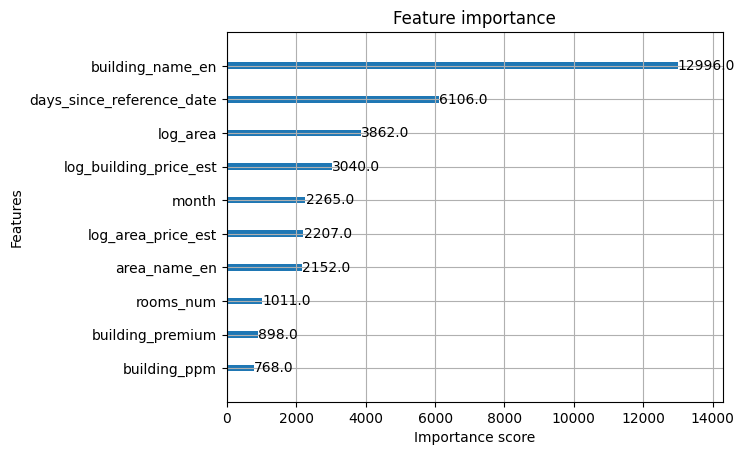

In [251]:
from sklearn.metrics import mean_absolute_error
# Predict
preds_log = model.predict(X_test)

# Convert back from Log to actual Price
preds_actual = np.expm1(preds_log)
y_test_actual = np.expm1(y_test)

# Calculate Mean Absolute Error (Average error in price)
mae = mean_absolute_error(y_test_actual, preds_actual)
print(f"Average Prediction Error: {mae:.2f}")

# Feature Importance: See what actually drives the price
xgb.plot_importance(model, max_num_features=10)

In [252]:
from sklearn.metrics import median_absolute_error
med_ae = median_absolute_error(y_test_actual, preds_actual)
print(f"Median Error: {med_ae}")

Median Error: 69841.56249999942


In [253]:
prices = np.expm1(y)
prices

0        1,450,000.00000
16         725,888.00000
7        1,417,888.00000
1          800,000.00000
2          320,000.00000
               ...      
348084   2,150,000.00000
348401     750,000.00000
348391   3,248,000.00000
348371   8,227,000.00000
348409     465,000.00000
Name: actual_worth_log, Length: 348410, dtype: float64

In [254]:
median_price = prices.median()
print("Median price:", median_price)

Median price: 1290000.0000000007


In [255]:
relative_error = (med_ae / median_price) * 100
print(f"Relative error: {relative_error:.2f}%")

Relative error: 5.41%


In [256]:
X_train.columns

Index(['building_name_en', 'area_name_en', 'rooms_num', 'log_area',
       'building_ppm', 'building_premium', 'log_building_premium',
       'log_building_price_est', 'log_area_price_est',
       'days_since_reference_date', 'year', 'month', 'quarter'],
      dtype='str')

In [257]:
check_df = flats_df22[(flats_df22['building_name_en'] == 'Socio Tower 2') & (flats_df22['rooms_num'] == 1)]
check_df['price'] = np.expm1(check_df['actual_worth_log'])
check_df.sort_values(by='days_since_reference_date', ascending=False)[:10]

,procedure_name_en,reg_type_id,reg_type_en,building_name_en,project_name_en,master_project_en,nearest_landmark_en,nearest_metro_en,nearest_mall_en,has_parking,procedure_area,actual_worth,meter_sale_price,parsed_date,area_name_en,rooms_num,actual_worth_log,days_since_reference_date,price
1664847,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,45.01000,"1,226,000.00000","27,238.39000",2025-11-27,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,14.01927,910,"1,226,000.00000"
779045,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,44.80000,"816,000.00000","18,214.29000",2025-11-20,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,13.61217,903,"816,000.00000"
1534180,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,44.90000,"1,280,000.00000","28,507.80000",2025-10-07,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,14.06237,859,"1,280,000.00000"
596792,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,45.34000,"1,260,000.00000","27,790.03000",2025-08-15,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,14.04662,806,"1,260,000.00000"
388319,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,45.34000,"1,300,000.00000","28,672.25000",2025-06-23,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,14.07788,753,"1,300,000.00000"
1065045,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,44.10000,"1,300,000.00000","29,478.46000",2025-05-15,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,14.07788,714,"1,300,000.00000"
414143,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,43.89000,"1,300,000.00000","29,619.50000",2025-04-29,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,14.07788,698,"1,300,000.00000"
310041,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,43.94000,"1,300,000.00000","29,585.80000",2025-04-29,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,14.07788,698,"1,300,000.00000"
649040,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,44.11000,"1,200,000.00000","27,204.72000",2024-11-28,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,13.99783,546,"1,200,000.00000"
805065,Sell,1,Existing Properties,Socio Tower 2,Socio,Dubai Hills Estate,Burj Al Arab,First Abu Dhabi Bank Metro Station,Mall of the Emirates,1,43.89000,"1,225,000.00000","27,910.69000",2024-07-19,Hadaeq Sheikh Mohammed Bin Rashid,1.00000,14.01845,414,"1,225,000.00000"


In [258]:
from datetime import datetime, date

def get_date_features(date_str=None):
    """
    Returns:
    - days difference from 2023-06-02
    - year
    - month
    - quarter
    """
    base_date = date(2023, 6, 2)

    # Use today's date if no date string provided
    if not date_str:
        input_date = date.today()
    else:
        input_date = datetime.strptime(date_str, "%d-%m-%Y").date()

    days_diff = (input_date - base_date).days
    year = input_date.year
    month = input_date.month
    quarter = (month - 1) // 3 + 1

    return days_diff, year, month, quarter


# Examples
print(get_date_features("15-10-2020"))
print(get_date_features())        # uses today's date
print(get_date_features(None))    # also uses today's date

(-960, 2020, 10, 4)
(1021, 2026, 3, 1)
(1021, 2026, 3, 1)


In [259]:
X_train.columns

Index(['building_name_en', 'area_name_en', 'rooms_num', 'log_area',
       'building_ppm', 'building_premium', 'log_building_premium',
       'log_building_price_est', 'log_area_price_est',
       'days_since_reference_date', 'year', 'month', 'quarter'],
      dtype='str')

In [260]:
building_area_map = {b: a for b, a in zip(df['building_name_en'], df['area_name_en'])}

In [261]:
building_ppm_map = (
    flats_df28.groupby("building_name_en")["building_ppm"]
    .median()
    .to_dict()
)

area_ppm_map = (
    flats_df28.groupby("area_name_en")["area_ppm"]
    .median()
    .to_dict()
)

In [262]:
building_ppm_6m_map = flats_df29.groupby("building_name_en")["building_ppm_6m"].median()
area_ppm_map = flats_df29.groupby("area_name_en")["area_ppm"].median()
area_ppm_3m_map = flats_df29.groupby("area_name_en")["area_ppm_3m"].median()

In [263]:
df_status(flats_df29)

348,410 Samples & 27 Features


In [ ]:
import pickle

with open('dubai_flats_prices.pickle', 'wb') as f:
    pickle.dump(model, f)

In [299]:
def comparable_transactions(building_name_en,
                  procedure_area, rooms_num,
                days_since_reference_date):
    same_building_txns = final_df[final_df['building_name_en'] == building_name_en]
    similar_rooms_txns = same_building_txns[same_building_txns['rooms_num'].between(rooms_num - 1, rooms_num + 1)]
    similar_rooms_txns['procedure_area'] = np.expm1(similar_rooms_txns['log_area'])
    similar_size_txns = similar_rooms_txns[(similar_rooms_txns['procedure_area'] >= 0.7 * procedure_area) & (similar_rooms_txns['procedure_area'] <= 1.2 * procedure_area)]
    recent_txns = similar_size_txns[similar_size_txns['days_since_reference_date'].between(days_since_reference_date - 200, days_since_reference_date + 50)]
    recent_txns['price'] = np.round(np.expm1(recent_txns['actual_worth_log']))
    return recent_txns.sort_values('days_since_reference_date', ascending=False)[['building_name_en', 'area_name_en', 'rooms_num', 'price']][:5].to_dict(orient='records')

In [305]:
import pickle
import numpy as np
import pandas as pd

def predict_price(building_name_en,
                  procedure_area, rooms_num):

    if building_name_en not in building_area_map:
        return None, None
    
    
    area_name_en = building_area_map[building_name_en]

    building_ppm = building_ppm_map.get(building_name_en, np.nan)
    if pd.isna(building_ppm):
        building_ppm = area_ppm
    area_ppm = area_ppm_map.get(area_name_en, np.nan)
    
    building_premium = (
        building_ppm / area_ppm
        if pd.notna(building_ppm) and pd.notna(area_ppm) and area_ppm > 0
        else np.nan
    )

    building_price_est = (
    building_ppm * procedure_area if pd.notna(building_ppm) else np.nan
    )
    
    area_price_est = (
        area_ppm * procedure_area if pd.notna(area_ppm) else np.nan
    )
    
    log_building_price_est = np.log1p(building_price_est) if pd.notna(building_price_est) else np.nan
    log_area_price_est = np.log1p(area_price_est) if pd.notna(area_price_est) else np.nan

    building_ppm_6m = building_ppm_6m_map.get(building_name_en, np.nan)

    building_discount = building_ppm_6m - area_ppm
        
    active_model = globals().get('model')
    if active_model is None:
        with open('dubai_flats_prices.pickle', 'rb') as f:
            active_model = pickle.load(f)

    days_since_reference_date, year, month, quarter = get_date_features()
    log_area = np.log1p(procedure_area)

    row = {
        'building_name_en': building_name_en,
        'area_name_en': area_name_en,
        # 'procedure_area': float(procedure_area),
        'rooms_num': float(rooms_num),
        'log_area': log_area,

        # "building_ppm_6m": building_ppm_6m,
    
        'building_ppm': building_ppm,
        # "area_ppm": area_ppm,
        # "area_ppm_3m": area_ppm_3m_map.get(area_name_en, np.nan),
        
        "building_premium": building_premium,
        # "building_ppm_6m": building_ppm_6m,
        'log_building_premium': np.log1p(building_premium),

        "log_building_price_est": log_building_price_est,
        "log_area_price_est": log_area_price_est,
    
        'days_since_reference_date': days_since_reference_date,
        'year': int(year),
        'month': int(month),
        'quarter': int(quarter),
    }

    x = pd.DataFrame([row])
    # print(x.T)
    

    if hasattr(active_model, 'feature_names_in_'):
        feature_order = list(active_model.feature_names_in_)
    elif 'X_train' in globals():
        feature_order = list(X_train.columns)
    else:
        feature_order = list(x.columns)

    for col in feature_order:
        if col not in x.columns:
            x[col] = np.nan
    x = x[feature_order]

    
    categorical_cols = x.select_dtypes(include='str')
    for col in categorical_cols:
        if col in x.columns:
            x[col] = x[col].astype('category')

    log_price = float(active_model.predict(x)[0])
    price = np.expm1(log_price)

    related_transactions = X[X.building_name_en == building_name_en]
    return price, comparable_transactions(building_name_en,
                  procedure_area, rooms_num,
                days_since_reference_date)

In [306]:
price, related_transactions = predict_price('Socio Tower 2', 45, 1)
print(price)
print(related_transactions)

1329717.9635951936
[{'building_name_en': 'Socio Tower 2', 'area_name_en': 'Hadaeq Sheikh Mohammed Bin Rashid', 'rooms_num': 1.0, 'price': 1226000.0}, {'building_name_en': 'Socio Tower 2', 'area_name_en': 'Hadaeq Sheikh Mohammed Bin Rashid', 'rooms_num': 1.0, 'price': 816000.0}, {'building_name_en': 'Socio Tower 2', 'area_name_en': 'Hadaeq Sheikh Mohammed Bin Rashid', 'rooms_num': 1.0, 'price': 1280000.0}]


In [310]:
price, related_transactions = predict_price('Seven City JLT', 83, 1)
print(price)
print(related_transactions)
# print(related_transactions[['building_name_en', 'procedure_area', 'price',]])

1381080.146139009
[{'building_name_en': 'Seven City JLT', 'area_name_en': 'Al Thanyah Fifth', 'rooms_num': 1.0, 'price': 885000.0}, {'building_name_en': 'Seven City JLT', 'area_name_en': 'Al Thanyah Fifth', 'rooms_num': 1.0, 'price': 950000.0}, {'building_name_en': 'Seven City JLT', 'area_name_en': 'Al Thanyah Fifth', 'rooms_num': 1.0, 'price': 950000.0}, {'building_name_en': 'Seven City JLT', 'area_name_en': 'Al Thanyah Fifth', 'rooms_num': 1.0, 'price': 850000.0}, {'building_name_en': 'Seven City JLT', 'area_name_en': 'Al Thanyah Fifth', 'rooms_num': 1.0, 'price': 760000.0}]


In [308]:
price, related_transactions = predict_price('PRINCESS TOWERY', 114, 2)
print(price)
# print(related_transactions[['building_name_en', 'procedure_area', 'price',]])

None


In [270]:
flats_df28.columns

Index(['procedure_name_en', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'parsed_date', 'area_name_en',
       'rooms_num', 'actual_worth_log', 'days_since_reference_date', 'year',
       'month', 'quarter', 'building_ppm', 'area_ppm', 'building_premium',
       'log_building_premium', 'log_area', 'building_ppm_6m', 'area_ppm_3m',
       'building_discount', 'building_price_est', 'log_building_price_est',
       'area_price_est', 'log_area_price_est'],
      dtype='str')

In [271]:
recent = flats_df28[
    (flats_df28["building_name_en"] == "Seven City JLT") &
    (flats_df28["year"] >= 2024)
]

recent["meter_sale_price"].median()

np.float64(15548.07)

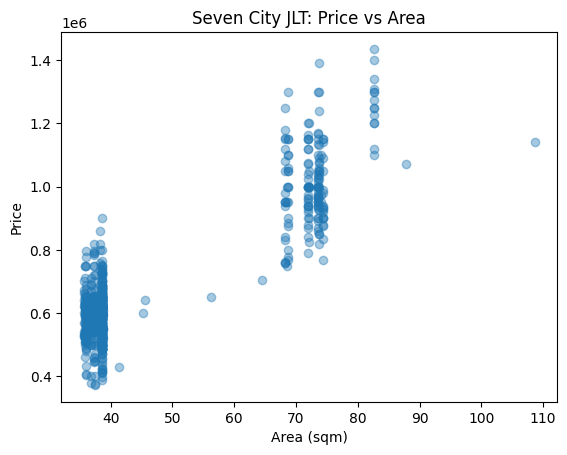

In [272]:
import matplotlib.pyplot as plt

b = flats_df28[(flats_df28["building_name_en"] == "Seven City JLT") & (flats_df28["rooms_num"] == 1)]

plt.scatter(b["procedure_area"], b["actual_worth"], alpha=0.4)
plt.xlabel("Area (sqm)")
plt.ylabel("Price")
plt.title("Seven City JLT: Price vs Area")
plt.show()

In [273]:
b[(b["rooms_num"] == 1) & (b["procedure_area"].between(32,38))]["actual_worth"].median()

np.float64(590000.0)

In [274]:
# import pickle

# with open('dubai_flats_prices.pickle', 'wb') as f:
#     pickle.dump(model, f)

In [275]:
flats_df28.columns

Index(['procedure_name_en', 'reg_type_en', 'building_name_en',
       'project_name_en', 'master_project_en', 'nearest_landmark_en',
       'nearest_metro_en', 'nearest_mall_en', 'has_parking', 'procedure_area',
       'actual_worth', 'meter_sale_price', 'parsed_date', 'area_name_en',
       'rooms_num', 'actual_worth_log', 'days_since_reference_date', 'year',
       'month', 'quarter', 'building_ppm', 'area_ppm', 'building_premium',
       'log_building_premium', 'log_area', 'building_ppm_6m', 'area_ppm_3m',
       'building_discount', 'building_price_est', 'log_building_price_est',
       'area_price_est', 'log_area_price_est'],
      dtype='str')

In [276]:
flats_df28[flats_df28["area_name_en"]=="Al Thanyah Fifth"]["meter_sale_price"].median()

np.float64(20989.8)

In [277]:
model.get_booster().feature_names

['building_name_en',
 'area_name_en',
 'rooms_num',
 'log_area',
 'building_ppm',
 'building_premium',
 'log_building_premium',
 'log_building_price_est',
 'log_area_price_est',
 'days_since_reference_date',
 'year',
 'month',
 'quarter']